# Per-Bit Analysis of Morgan Fingerprint Predictions

**Model**: Fine-tuned DreaMS → 2048-bit Morgan fingerprint (ECFP4, radius 2)  
**Primary evaluation set**: `probing_test` (45,185 spectra) — out-of-distribution test  
**Secondary evaluation set**: Fine-tuning `val` split — in-distribution validation  
**Loss**: Cosine similarity  
**Checkpoint**: `epoch=53-step=7000.ckpt` (best by cosine similarity on probing_test)

This notebook performs:
1. Extraction of raw predictions and ground truth
2. Output distribution analysis  
3. Global threshold sweep (precision, recall, F1, Tanimoto)
4. Per-bit AUROC analysis
5. AUROC vs frequency scatter
6. Chemical interpretation of best/worst predicted bits
7. Bit-level performance grouped by chemical category
8. Summary statistics table

In [14]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import torch
import h5py
import matplotlib
# matplotlib.use('Agg')  # Non-interactive backend (disabled for notebook display)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr
from collections import defaultdict, Counter

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors

# DreaMS imports
from dreams.models.heads.heads import FingerprintHead
from dreams.models.dreams.dreams import DreaMS
import dreams.utils.data as du
import dreams.utils.dformats as dformats

# Reproducibility
SEED = 3407
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
CKPT_PATH = Path('/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=53-step=7000.ckpt')
PROBING_TEST_PATH = Path(PROJECT_ROOT) / 'dreams-thesis-wa/data/processed/MassSpecGym_splits/probing_test.parquet'
FINETUNING_HDF5_PATH = Path(PROJECT_ROOT) / 'dreams-thesis-wa/data/processed/MassSpecGym_splits/finetuning.hdf5'
OUTPUT_DIR = Path(PROJECT_ROOT) / 'dreams-thesis-wa/results/per_bit_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Probing test: {PROBING_TEST_PATH}")
print(f"Output: {OUTPUT_DIR}")

Device: mps
Checkpoint: /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=53-step=7000.ckpt
Probing test: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/data/processed/MassSpecGym_splits/probing_test.parquet
Output: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis


## 1. Load Model and Data, Extract Predictions

Load the fine-tuned FingerprintHead checkpoint and the probing_test set (45,185 spectra).  
Compute ground truth Morgan fingerprints from SMILES, run inference to get predictions.

In [15]:
# ── Load the probing_test parquet ──
df_test = pd.read_parquet(PROBING_TEST_PATH)
print(f"Probing test set: {len(df_test)} spectra")
print(f"Columns: {list(df_test.columns)}")

smiles_list = df_test['smiles'].tolist()
print(f"Sample SMILES: {smiles_list[0]}")

Probing test set: 45185 spectra
Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'simulation_challenge', 'scaffold_id', 'murcko_scaffold', 'ecfp4', 'map4', 'embedding', 'ssl_embedding', 'alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score', 'fold', 'original_fold']
Sample SMILES: C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1


In [16]:
# ── Compute ground truth Morgan fingerprints from SMILES ──
FP_SIZE = 2048
RADIUS = 2

def compute_morgan_fp(smi, fp_size=FP_SIZE, radius=RADIUS):
    """Compute binary Morgan fingerprint as numpy array."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(fp_size, dtype=np.float32)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_size)
    return np.array(fp, dtype=np.float32)

# Check cache first
y_true_path = OUTPUT_DIR / 'y_true.npy'
smiles_path = OUTPUT_DIR / 'smiles.npy'

if y_true_path.exists() and smiles_path.exists():
    print("⚡ Loading cached ground truth Morgan fingerprints...")
    y_true = np.load(y_true_path)
    cached_smiles = np.load(smiles_path, allow_pickle=True)
    # Verify cache matches current data
    if len(cached_smiles) == len(smiles_list) and np.array_equal(cached_smiles, smiles_list):
        print(f"✓ Cache valid: {y_true.shape}")
    else:
        print("⚠ Cache mismatch, recomputing...")
        y_true = np.stack([compute_morgan_fp(s) for s in tqdm(smiles_list, desc="Morgan FPs")])
        np.save(y_true_path, y_true)
        np.save(smiles_path, np.array(smiles_list))
else:
    print("Computing ground truth Morgan fingerprints...")
    y_true = np.stack([compute_morgan_fp(s) for s in tqdm(smiles_list, desc="Morgan FPs")])
    np.save(y_true_path, y_true)
    np.save(smiles_path, np.array(smiles_list))

print(f"y_true shape: {y_true.shape}, dtype: {y_true.dtype}")
print(f"Mean bits active per spectrum: {y_true.sum(axis=1).mean():.1f}")
print(f"Sparsity: {y_true.mean():.4f} (fraction of 1s)")

⚡ Loading cached ground truth Morgan fingerprints...
✓ Cache valid: (45185, 2048)
y_true shape: (45185, 2048), dtype: float32
Mean bits active per spectrum: 43.0
Sparsity: 0.0210 (fraction of 1s)


In [17]:
# ── Load the fine-tuned model ──
import pathlib
from dreams.definitions import PRETRAINED
from unittest.mock import patch as _mock_patch

print(f"Loading FingerprintHead from {CKPT_PATH.name}...")

# PyTorch 2.9 defaults to weights_only=True, but checkpoint contains
# pickled custom classes (DreaMS, PosixPath, etc.).
# Monkeypatch torch.load to use weights_only=False during loading.
_original_torch_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _original_torch_load(*args, **kwargs)

with _mock_patch('torch.load', _patched_load):
    model = FingerprintHead.load_from_checkpoint(
        str(CKPT_PATH),
        backbone=PRETRAINED / 'ssl_model.ckpt',
        map_location=torch.device('cpu')
    )

model = model.eval().float()  # Ensure float32
model = model.to(DEVICE)
print(f"Model loaded on {DEVICE}. Head type: {type(model.head)}")
print(f"FP string: {model.fp_str}, FP size: {model.fp_size}")
print(f"Backbone d_model: {model.backbone.d_model}")

Loading FingerprintHead from epoch=53-step=7000.ckpt...
Model loaded on mps. Head type: <class 'dreams.models.baselines.deep_sets.DeepSets'>
FP string: fp_morgan_2048, FP size: 2048
Backbone d_model: 1024


In [18]:
# ── Prepare spectra from probing_test parquet for DreaMS inference ──
# The probing_test parquet stores mzs and intensities as comma-separated strings.
# We need to convert them to the (2, n_peaks) numpy arrays that SpectrumPreprocessor expects.

spec_preproc = du.SpectrumPreprocessor(
    dformat=dformats.DataFormatA(),
    prec_intens=1.1,
    n_highest_peaks=100  # Same as training
)

def parse_spectrum(mzs_str, intensities_str):
    """Parse comma-separated mzs/intensities strings into (2, n_peaks) array."""
    mzs = np.fromstring(mzs_str, sep=',', dtype=np.float64)
    ints = np.fromstring(intensities_str, sep=',', dtype=np.float64)
    return np.stack([mzs, ints], axis=0)

# Check cache first
spectra_cache_path = OUTPUT_DIR / 'spectra_tensor.pt'

if spectra_cache_path.exists():
    print("⚡ Loading cached preprocessed spectra...")
    spectra_tensor = torch.load(spectra_cache_path)
    if len(spectra_tensor) == len(df_test):
        print(f"✓ Cache valid: {spectra_tensor.shape}")
    else:
        print("⚠ Cache size mismatch, reprocessing...")
        print("Preparing spectra for inference...")
        spectra_raw = []
        prec_mzs = df_test['precursor_mz'].values.astype(np.float64)
        for i in tqdm(range(len(df_test)), desc="Parsing spectra"):
            spec = parse_spectrum(df_test['mzs'].iloc[i], df_test['intensities'].iloc[i])
            spec_proc = spec_preproc(spec, prec_mz=prec_mzs[i], high_form=False)
            spectra_raw.append(spec_proc)
        spectra_tensor = torch.stack([torch.tensor(s, dtype=torch.float32) for s in spectra_raw])
        torch.save(spectra_tensor, spectra_cache_path)
else:
    print("Preparing spectra for inference...")
    spectra_raw = []
    prec_mzs = df_test['precursor_mz'].values.astype(np.float64)
    for i in tqdm(range(len(df_test)), desc="Parsing spectra"):
        spec = parse_spectrum(df_test['mzs'].iloc[i], df_test['intensities'].iloc[i])
        spec_proc = spec_preproc(spec, prec_mz=prec_mzs[i], high_form=False)
        spectra_raw.append(spec_proc)
    spectra_tensor = torch.stack([torch.tensor(s, dtype=torch.float32) for s in spectra_raw])
    torch.save(spectra_tensor, spectra_cache_path)
    
print(f"Spectra tensor shape: {spectra_tensor.shape}")  # (45185, n_peaks, 2)

⚡ Loading cached preprocessed spectra...
✓ Cache valid: torch.Size([45185, 101, 2])
Spectra tensor shape: torch.Size([45185, 101, 2])


In [19]:
# ── Run inference in batches ──
BATCH_SIZE = 64

# Check cache first
y_pred_path = OUTPUT_DIR / 'y_pred.npy'
cos_sims_path = OUTPUT_DIR / 'cos_sims.npy'

if y_pred_path.exists() and cos_sims_path.exists():
    print("⚡ Loading cached predictions...")
    y_pred = np.load(y_pred_path)
    cos_sims = np.load(cos_sims_path)
    if len(y_pred) == len(df_test) and y_pred.shape[1] == FP_SIZE:
        print(f"✓ Cache valid: {y_pred.shape}")
    else:
        print("⚠ Cache size mismatch, re-running inference...")
        y_pred = torch.zeros((len(df_test), FP_SIZE), dtype=torch.float32)
        print(f"Running inference on {len(df_test)} spectra (batch_size={BATCH_SIZE})...")
        model.eval()
        with torch.inference_mode():
            for start in tqdm(range(0, len(df_test), BATCH_SIZE), desc="Inference"):
                end = min(start + BATCH_SIZE, len(df_test))
                batch_spec = spectra_tensor[start:end].to(DEVICE)
                batch_charge = torch.ones(end - start, dtype=torch.float32, device=DEVICE)
                pred = model(batch_spec, batch_charge)
                y_pred[start:end] = pred.cpu()
        y_pred = y_pred.numpy()
        from numpy.linalg import norm
        cos_sims = np.array([
            np.dot(y_pred[i], y_true[i]) / (norm(y_pred[i]) * norm(y_true[i]) + 1e-8)
            for i in range(len(y_pred))
        ])
        np.save(y_pred_path, y_pred)
        np.save(cos_sims_path, cos_sims)
else:
    y_pred = torch.zeros((len(df_test), FP_SIZE), dtype=torch.float32)
    print(f"Running inference on {len(df_test)} spectra (batch_size={BATCH_SIZE})...")
    model.eval()
    with torch.inference_mode():
        for start in tqdm(range(0, len(df_test), BATCH_SIZE), desc="Inference"):
            end = min(start + BATCH_SIZE, len(df_test))
            batch_spec = spectra_tensor[start:end].to(DEVICE)
            batch_charge = torch.ones(end - start, dtype=torch.float32, device=DEVICE)
            pred = model(batch_spec, batch_charge)
            y_pred[start:end] = pred.cpu()
    y_pred = y_pred.numpy()
    from numpy.linalg import norm
    cos_sims = np.array([
        np.dot(y_pred[i], y_true[i]) / (norm(y_pred[i]) * norm(y_true[i]) + 1e-8)
        for i in range(len(y_pred))
    ])
    np.save(y_pred_path, y_pred)
    np.save(cos_sims_path, cos_sims)

print(f"y_pred shape: {y_pred.shape}, range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print(f"y_pred mean: {y_pred.mean():.4f}, std: {y_pred.std():.4f}")
print(f"\nMean cosine similarity: {cos_sims.mean():.4f} ± {cos_sims.std():.4f}")

⚡ Loading cached predictions...
✓ Cache valid: (45185, 2048)
y_pred shape: (45185, 2048), range: [-384.2497, 820.1191]
y_pred mean: 5.1061, std: 26.6973

Mean cosine similarity: 0.3902 ± 0.1295


In [20]:
# ── TEST ALL CHECKPOINTS: Find which one achieves 0.65 cosine similarity ──
# 
# Available checkpoints from snellius output:
# - epoch=53-step=7000.ckpt  (14:24)
# - epoch=60-step=8000.ckpt  (14:36)
# - epoch=68-step=9000.ckpt  (14:47)
# - last.ckpt                (14:54, final when EarlyStopping triggered)

CHECKPOINT_DIR = Path('/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317')

checkpoints_to_test = [
    ('epoch_53', CHECKPOINT_DIR / 'epoch=53-step=7000.ckpt'),
    ('epoch_60', CHECKPOINT_DIR / 'epoch=60-step=8000.ckpt'),
    ('epoch_68', CHECKPOINT_DIR / 'epoch=68-step=9000.ckpt'),
    ('last', CHECKPOINT_DIR / 'last.ckpt'),
]

results = []

for ckpt_name, ckpt_path in checkpoints_to_test:
    print(f"\n{'='*70}")
    print(f"Testing checkpoint: {ckpt_name}")
    print(f"Path: {ckpt_path}")
    print(f"Exists: {ckpt_path.exists()}")
    print('='*70)
    
    if not ckpt_path.exists():
        print(f"⚠️ Checkpoint not found, skipping...")
        continue
    
    try:
        # Load checkpoint
        print("Loading checkpoint...")
        with _mock_patch('torch.load', _patched_load):
            test_model = FingerprintHead.load_from_checkpoint(
                str(ckpt_path),
                backbone=PRETRAINED / 'ssl_model.ckpt',
                map_location=torch.device('cpu')
            )
        
        test_model = test_model.eval().float()
        test_model = test_model.to(DEVICE)
        print(f"✓ Model loaded on {DEVICE}")
        
        # Run inference on probing_test
        print(f"Running inference on {len(df_test)} spectra...")
        y_pred_test = torch.zeros((len(df_test), FP_SIZE), dtype=torch.float32)
        test_model.eval()
        
        with torch.inference_mode():
            for start in tqdm(range(0, len(df_test), BATCH_SIZE), desc=f"Inference ({ckpt_name})"):
                end = min(start + BATCH_SIZE, len(df_test))
                batch_spec = spectra_tensor[start:end].to(DEVICE)
                batch_charge = torch.ones(end - start, dtype=torch.float32, device=DEVICE)
                pred = test_model(batch_spec, batch_charge)
                y_pred_test[start:end] = pred.cpu()
        
        y_pred_test = y_pred_test.numpy()
        
        # Compute cosine similarity
        print("Computing cosine similarity...")
        from numpy.linalg import norm
        cos_sims_test = np.array([
            np.dot(y_pred_test[i], y_true[i]) / (norm(y_pred_test[i]) * norm(y_true[i]) + 1e-8)
            for i in range(len(y_pred_test))
        ])
        
        mean_cos_sim = cos_sims_test.mean()
        std_cos_sim = cos_sims_test.std()
        median_cos_sim = np.median(cos_sims_test)
        
        print(f"\n✓ Results for {ckpt_name}:")
        print(f"  Mean cosine similarity:   {mean_cos_sim:.4f} ± {std_cos_sim:.4f}")
        print(f"  Median cosine similarity: {median_cos_sim:.4f}")
        print(f"  Min:  {cos_sims_test.min():.4f}")
        print(f"  Max:  {cos_sims_test.max():.4f}")
        
        results.append({
            'checkpoint': ckpt_name,
            'path': str(ckpt_path),
            'mean_cosine_sim': mean_cos_sim,
            'std_cosine_sim': std_cos_sim,
            'median_cosine_sim': median_cos_sim,
            'min_cosine_sim': cos_sims_test.min(),
            'max_cosine_sim': cos_sims_test.max(),
        })
        
        # Clean up to save memory
        del test_model, y_pred_test, cos_sims_test
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
    except Exception as e:
        print(f"❌ Error loading/testing {ckpt_name}: {e}")
        import traceback
        traceback.print_exc()

# Summary table
print(f"\n\n{'='*70}")
print("CHECKPOINT COMPARISON SUMMARY")
print('='*70)

if results:
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    
    # Find best by cosine similarity
    best_idx = results_df['mean_cosine_sim'].idxmax()
    best_ckpt = results_df.loc[best_idx]
    
    print(f"\n🏆 BEST CHECKPOINT (highest cosine similarity):")
    print(f"   {best_ckpt['checkpoint']}: {best_ckpt['mean_cosine_sim']:.4f}")
    print(f"   Path: {best_ckpt['path']}")
else:
    print("⚠️ No checkpoints were successfully tested")


Testing checkpoint: epoch_53
Path: /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=53-step=7000.ckpt
Exists: True
Loading checkpoint...
✓ Model loaded on mps
Running inference on 45185 spectra...


Inference (epoch_53):   0%|          | 0/707 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 1.5. Apples-to-Apples Comparison: In-Distribution (Val) vs Out-of-Distribution (Probing_Test)

To disentangle whether the performance gap is due to generalization loss or checkpoint selection,  
evaluate `epoch=53` on both fine-tuning **validation** (in-distribution) and **probing_test** (out-of-distribution).  
This reveals the true generalization gap and validates that epoch=53 is methodologically sound.

In [21]:
# ── Apples-to-Apples: In-Distribution (Val) vs Out-of-Distribution (Probing_Test) ──
print("="*70)
print("APPLES-TO-APPLES EVALUATION: In-Distribution vs Out-of-Distribution")
print("="*70)

# ── 1. Load fine-tuning validation split from HDF5 ──
with h5py.File(FINETUNING_HDF5_PATH, 'r') as f:
    print(f"\nFinetuning HDF5 keys: {list(f.keys())}")
    
    fold_array = f['fold'][()].astype(str)
    all_smiles = f['smiles'][()].astype(str)
    all_prec_mz = f['precursor_mz'][()]
    all_spectra = f['spectrum'][()]  # (N, 2, 128) float32 — already preprocessed
    
    # Print fold distribution
    unique_folds, fold_counts = np.unique(fold_array, return_counts=True)
    print(f"Spectrum shape per sample: {all_spectra.shape[1:]}")
    print(f"\nFold distribution:")
    for fold, count in zip(unique_folds, fold_counts):
        print(f"  {fold}: {count:,}")
    
    # Filter for validation split
    val_mask = fold_array == 'val'
    if val_mask.sum() == 0:
        val_mask = fold_array == 'test'
        fold_name = 'test'
    else:
        fold_name = 'val'
    
    val_smiles = all_smiles[val_mask]
    val_prec_mz = all_prec_mz[val_mask]
    val_spectra_raw = all_spectra[val_mask]  # (N_val, 2, 128)
    
    print(f"\nValidation set (fold='{fold_name}'): {len(val_smiles):,} spectra")

# ── 2. Compute ground truth Morgan FPs for validation set ──
print("\nComputing ground truth Morgan FPs for validation set...")
y_true_val = np.stack([compute_morgan_fp(s) for s in tqdm(val_smiles, desc="Val Morgan FPs")])
print(f"Val y_true shape: {y_true_val.shape}")

# ── 3. Preprocess val spectra through SpectrumPreprocessor (same as probing_test) ──
# HDF5 stores (2, 128) "low form" — SpectrumPreprocessor transposes, trims/pads,
# prepends precursor peak, and normalizes m/z, matching probing_test pipeline.
print("Preprocessing validation spectra (same pipeline as probing_test)...")
val_spectra_processed = []
for i in tqdm(range(len(val_smiles)), desc="Preprocessing val spectra"):
    spec_proc = spec_preproc(val_spectra_raw[i], prec_mz=val_prec_mz[i], high_form=False)
    val_spectra_processed.append(spec_proc)

val_spectra_tensor = torch.stack([torch.tensor(s, dtype=torch.float32) for s in val_spectra_processed])
print(f"Val spectra tensor shape: {val_spectra_tensor.shape}")

# ── 4. Run inference on validation set with epoch=53 (best.ckpt) ──
print(f"\nRunning inference on validation set with {CKPT_PATH.name}...")
y_pred_val = torch.zeros((len(val_smiles), FP_SIZE), dtype=torch.float32)

model.eval()
with torch.inference_mode():
    for start in tqdm(range(0, len(val_smiles), BATCH_SIZE), desc="Inference (val)"):
        end = min(start + BATCH_SIZE, len(val_smiles))
        batch_spec = val_spectra_tensor[start:end].to(DEVICE)
        batch_charge = torch.ones(end - start, dtype=torch.float32, device=DEVICE)
        pred = model(batch_spec, batch_charge)
        y_pred_val[start:end] = pred.cpu()

y_pred_val = y_pred_val.numpy()

# ── 5. Compute cosine similarity for validation set ──
from numpy.linalg import norm
cos_sims_val = np.array([
    np.dot(y_pred_val[i], y_true_val[i]) / (norm(y_pred_val[i]) * norm(y_true_val[i]) + 1e-8)
    for i in range(len(y_pred_val))
])

# ── 6. Determine threshold ──
# Use OPTIMAL_THRESHOLD if already computed (from threshold sweep cell),
# otherwise compute it here on probing_test predictions.
try:
    tau = OPTIMAL_THRESHOLD
    print(f"\nUsing pre-computed optimal threshold: τ={tau:.2f}")
except NameError:
    print("\nOPTIMAL_THRESHOLD not yet defined — computing threshold sweep on probing_test...")
    from sklearn.metrics import f1_score as _f1
    best_tan, best_tau = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        yb = (y_pred >= t).astype(int)
        inter = np.logical_and(yb, y_true).sum(axis=1)
        union = np.logical_or(yb, y_true).sum(axis=1)
        tan_mean = np.where(union > 0, inter / union, 0.0).mean()
        if tan_mean > best_tan:
            best_tan, best_tau = tan_mean, t
    tau = best_tau
    OPTIMAL_THRESHOLD = tau
    print(f"  Optimal threshold (by mean Tanimoto): τ={tau:.2f} → Tanimoto={best_tan:.4f}")

# ── 7. Compute Tanimoto on both sets at the SAME threshold ──
print(f"\nComputing Tanimoto similarity at τ={tau:.2f}...")

# Validation set
y_bin_val = (y_pred_val >= tau).astype(int)
inter_val = np.logical_and(y_bin_val, y_true_val).sum(axis=1)
union_val = np.logical_or(y_bin_val, y_true_val).sum(axis=1)
tanimoto_val = np.where(union_val > 0, inter_val / union_val, 0.0)

# Probing test (using y_pred / y_true from earlier cells)
y_bin_test = (y_pred >= tau).astype(int)
inter_test = np.logical_and(y_bin_test, y_true).sum(axis=1)
union_test = np.logical_or(y_bin_test, y_true).sum(axis=1)
tanimoto_test = np.where(union_test > 0, inter_test / union_test, 0.0)

# ── 8. Print comparison table ──
print("\n" + "="*70)
print("COMPARISON: IN-DISTRIBUTION (Val) vs OUT-OF-DISTRIBUTION (Probing_Test)")
print(f"Checkpoint: {CKPT_PATH.name}  |  Threshold τ={tau:.2f}")
print("="*70)

comparison_data = {
    'Metric': [
        'Set size',
        'Mean cosine similarity',
        'Std cosine similarity',
        'Median cosine similarity',
        f'Mean Tanimoto @ τ={tau:.2f}',
        f'Std Tanimoto @ τ={tau:.2f}',
        f'Median Tanimoto @ τ={tau:.2f}',
        'Min Tanimoto',
        'Max Tanimoto',
    ],
    'Validation (In-Dist)': [
        f'{len(val_smiles):,}',
        f'{cos_sims_val.mean():.4f}',
        f'{cos_sims_val.std():.4f}',
        f'{np.median(cos_sims_val):.4f}',
        f'{tanimoto_val.mean():.4f}',
        f'{tanimoto_val.std():.4f}',
        f'{np.median(tanimoto_val):.4f}',
        f'{tanimoto_val.min():.4f}',
        f'{tanimoto_val.max():.4f}',
    ],
    'Probing_Test (OOD)': [
        f'{len(df_test):,}',
        f'{cos_sims.mean():.4f}',
        f'{cos_sims.std():.4f}',
        f'{np.median(cos_sims):.4f}',
        f'{tanimoto_test.mean():.4f}',
        f'{tanimoto_test.std():.4f}',
        f'{np.median(tanimoto_test):.4f}',
        f'{tanimoto_test.min():.4f}',
        f'{tanimoto_test.max():.4f}',
    ],
}

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

# Generalization gap
gap_cosine = cos_sims_val.mean() - cos_sims.mean()
gap_tanimoto = tanimoto_val.mean() - tanimoto_test.mean()

print(f"\n{'─'*70}")
print(f"GENERALIZATION GAP (Val → Probing_Test):")
print(f"  Cosine similarity drop:   {gap_cosine:+.4f} ({gap_cosine/cos_sims_val.mean()*100:+.1f}%)")
print(f"  Tanimoto similarity drop: {gap_tanimoto:+.4f} ({gap_tanimoto/tanimoto_val.mean()*100:+.1f}%)")
print(f"  → Larger drop = more distribution shift; smaller = better generalization")
print(f"{'─'*70}")

# Save comparison
comparison_data['Gap (Val - OOD)'] = [
    '',
    f'{gap_cosine:+.4f}',
    '',
    f'{(np.median(cos_sims_val) - np.median(cos_sims)):+.4f}',
    f'{gap_tanimoto:+.4f}',
    '',
    f'{(np.median(tanimoto_val) - np.median(tanimoto_test)):+.4f}',
    '',
    '',
]
pd.DataFrame(comparison_data).to_csv(OUTPUT_DIR / 'apples_to_apples_comparison.csv', index=False)
print(f"\nSaved to: {OUTPUT_DIR / 'apples_to_apples_comparison.csv'}")

APPLES-TO-APPLES EVALUATION: In-Distribution vs Out-of-Distribution

Finetuning HDF5 keys: ['adduct', 'fold', 'precursor_mz', 'smiles', 'spectrum']
Spectrum shape per sample: (2, 128)

Fold distribution:
  train: 135,856
  val: 23,415

Validation set (fold='val'): 23,415 spectra

Computing ground truth Morgan FPs for validation set...


Val Morgan FPs:   0%|          | 0/23415 [00:00<?, ?it/s]

Val y_true shape: (23415, 2048)
Preprocessing validation spectra (same pipeline as probing_test)...


Preprocessing val spectra:   0%|          | 0/23415 [00:00<?, ?it/s]

Val spectra tensor shape: torch.Size([23415, 101, 2])

Running inference on validation set with epoch=53-step=7000.ckpt...


Inference (val):   0%|          | 0/366 [00:00<?, ?it/s]


OPTIMAL_THRESHOLD not yet defined — computing threshold sweep on probing_test...
  Optimal threshold (by mean Tanimoto): τ=0.94 → Tanimoto=0.0294

Computing Tanimoto similarity at τ=0.94...

COMPARISON: IN-DISTRIBUTION (Val) vs OUT-OF-DISTRIBUTION (Probing_Test)
Checkpoint: epoch=53-step=7000.ckpt  |  Threshold τ=0.94
                  Metric Validation (In-Dist) Probing_Test (OOD)
                Set size               23,415             45,185
  Mean cosine similarity               0.6353             0.3902
   Std cosine similarity               0.2327             0.1295
Median cosine similarity               0.6331             0.3769
  Mean Tanimoto @ τ=0.94               0.0405             0.0294
   Std Tanimoto @ τ=0.94               0.0180             0.0119
Median Tanimoto @ τ=0.94               0.0372             0.0279
            Min Tanimoto               0.0042             0.0048
            Max Tanimoto               0.0955             0.1053

────────────────────────────

## 1.6. Per-Bit AUROC Comparison: In-Distribution vs Out-of-Distribution

**Goal**: Compare per-bit AUROC between validation (in-dist) and probing_test (OOD) to identify which bits generalize well and which suffer from distribution shift.

**Key questions**:
- Is the generalization gap uniform across all bits, or concentrated in specific substructure types?
- Do rare bits or common bits suffer more from OOD generalization?
- Which bits are most vulnerable to scaffold-based distribution shift?

In [22]:
# ── Cache validation predictions for retrieval evaluation ──
# Save y_pred_val and y_true_val so retrieval evaluation can access them

print("\n" + "="*70)
print("CACHING VALIDATION PREDICTIONS")
print("="*70)

# Save validation predictions to cache files
np.save(OUTPUT_DIR / 'y_pred_val.npy', y_pred_val)
np.save(OUTPUT_DIR / 'y_true_val.npy', y_true_val)

print(f"✓ Saved y_pred_val: {y_pred_val.shape}")
print(f"✓ Saved y_true_val: {y_true_val.shape}")
print(f"  Cache location: {OUTPUT_DIR}")
print(f"  Files: y_pred_val.npy, y_true_val.npy")
print(f"\nThese cached predictions can be loaded by standalone scripts for retrieval evaluation.")


CACHING VALIDATION PREDICTIONS
✓ Saved y_pred_val: (23415, 2048)
✓ Saved y_true_val: (23415, 2048)
  Cache location: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis
  Files: y_pred_val.npy, y_true_val.npy

These cached predictions can be loaded by standalone scripts for retrieval evaluation.


In [54]:
# ── Step 1: Verify predictions are loaded for both splits ──
print("="*70)
print("PER-BIT AUROC COMPARISON: Validation vs Probing_Test (OOD)")
print("="*70)

# Create output directory for this analysis
AUROC_COMPARISON_DIR = OUTPUT_DIR / 'per_bit_auroc'
AUROC_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Check if we have all the required data
try:
    # Validation split (from previous cell)
    print(f"\n✓ Validation predictions loaded: {y_pred_val.shape}")
    print(f"✓ Validation ground truth loaded: {y_true_val.shape}")
    print(f"  N spectra: {len(y_pred_val):,}")
    
    # OOD split (from earlier cells)
    print(f"\n✓ OOD (probing_test) predictions loaded: {y_pred.shape}")
    print(f"✓ OOD ground truth loaded: {y_true.shape}")
    print(f"  N spectra: {len(y_pred):,}")
    
    print(f"\n✓ All data ready for per-bit AUROC comparison")
    
except NameError as e:
    print(f"\n❌ ERROR: Required variables not found: {e}")
    print("   Please run the previous 'Apples-to-Apples' cell first to generate validation predictions.")

PER-BIT AUROC COMPARISON: Validation vs Probing_Test (OOD)

✓ Validation predictions loaded: (23415, 2048)
✓ Validation ground truth loaded: (23415, 2048)
  N spectra: 23,415

✓ OOD (probing_test) predictions loaded: (45185, 2048)
✓ OOD ground truth loaded: (45185, 2048)
  N spectra: 45,185

✓ All data ready for per-bit AUROC comparison


In [55]:
# ── Step 2: Compute per-bit AUROC on both splits ──
from sklearn.metrics import roc_auc_score

# Check cache first
auroc_comp_cache = AUROC_COMPARISON_DIR / 'auroc_comparison.csv'

if auroc_comp_cache.exists():
    print("⚡ Loading cached per-bit AUROC comparison...")
    auroc_df = pd.read_csv(auroc_comp_cache)
    print(f"✓ Cache loaded: {len(auroc_df)} bits")
else:
    print("\nComputing per-bit AUROC for both splits...")
    n_bits = 2048
    results = []
    
    for bit_idx in tqdm(range(n_bits), desc="Per-bit AUROC comparison"):
        row = {'bit_index': bit_idx}
        
        # Validation split
        y_t_val = y_true_val[:, bit_idx]
        y_p_val = y_pred_val[:, bit_idx]
        pos_val = int(y_t_val.sum())
        neg_val = len(y_t_val) - pos_val
        freq_val = pos_val / len(y_t_val)
        
        if pos_val == 0 or neg_val == 0:
            auroc_val = np.nan
        else:
            auroc_val = roc_auc_score(y_t_val, y_p_val)
        
        row['auroc_val'] = auroc_val
        row['freq_val'] = freq_val
        row['n_pos_val'] = pos_val
        
        # OOD split (probing_test)
        y_t_ood = y_true[:, bit_idx]
        y_p_ood = y_pred[:, bit_idx]
        pos_ood = int(y_t_ood.sum())
        neg_ood = len(y_t_ood) - pos_ood
        freq_ood = pos_ood / len(y_t_ood)
        
        if pos_ood == 0 or neg_ood == 0:
            auroc_ood = np.nan
        else:
            auroc_ood = roc_auc_score(y_t_ood, y_p_ood)
        
        row['auroc_ood'] = auroc_ood
        row['freq_ood'] = freq_ood
        row['n_pos_ood'] = pos_ood
        
        results.append(row)
    
    auroc_df = pd.DataFrame(results)
    auroc_df['auroc_drop'] = auroc_df['auroc_val'] - auroc_df['auroc_ood']
    auroc_df.to_csv(auroc_comp_cache, index=False)
    print(f"✓ Saved to: {auroc_comp_cache}")

# Filter valid bits (both classes present in BOTH splits)
valid_comp = auroc_df.dropna(subset=['auroc_val', 'auroc_ood'])

print(f"\n{'='*70}")
print(f"SUMMARY: Per-Bit AUROC Comparison")
print(f"{'='*70}")
print(f"Total bits:                 {len(auroc_df)}")
print(f"Valid bits (both splits):   {len(valid_comp)}")
print(f"Invalid (Val):              {auroc_df['auroc_val'].isna().sum()}")
print(f"Invalid (OOD):              {auroc_df['auroc_ood'].isna().sum()}")
print(f"\nAUROC Statistics (valid bits only):")
print(f"  Validation   — Mean: {valid_comp['auroc_val'].mean():.4f}, Median: {valid_comp['auroc_val'].median():.4f}, Std: {valid_comp['auroc_val'].std():.4f}")
print(f"  OOD          — Mean: {valid_comp['auroc_ood'].mean():.4f}, Median: {valid_comp['auroc_ood'].median():.4f}, Std: {valid_comp['auroc_ood'].std():.4f}")
print(f"  Drop (V→OOD) — Mean: {valid_comp['auroc_drop'].mean():.4f}, Median: {valid_comp['auroc_drop'].median():.4f}, Std: {valid_comp['auroc_drop'].std():.4f}")
print(f"\nGeneralization gap: {valid_comp['auroc_drop'].mean():.4f} AUROC points")
print(f"  → Positive drop = worse performance OOD")
print(f"{'='*70}")

⚡ Loading cached per-bit AUROC comparison...
✓ Cache loaded: 2048 bits

SUMMARY: Per-Bit AUROC Comparison
Total bits:                 2048
Valid bits (both splits):   2048
Invalid (Val):              0
Invalid (OOD):              0

AUROC Statistics (valid bits only):
  Validation   — Mean: 0.7711, Median: 0.7881, Std: 0.1094
  OOD          — Mean: 0.5910, Median: 0.5869, Std: 0.0961
  Drop (V→OOD) — Mean: 0.1801, Median: 0.1805, Std: 0.1280

Generalization gap: 0.1801 AUROC points
  → Positive drop = worse performance OOD


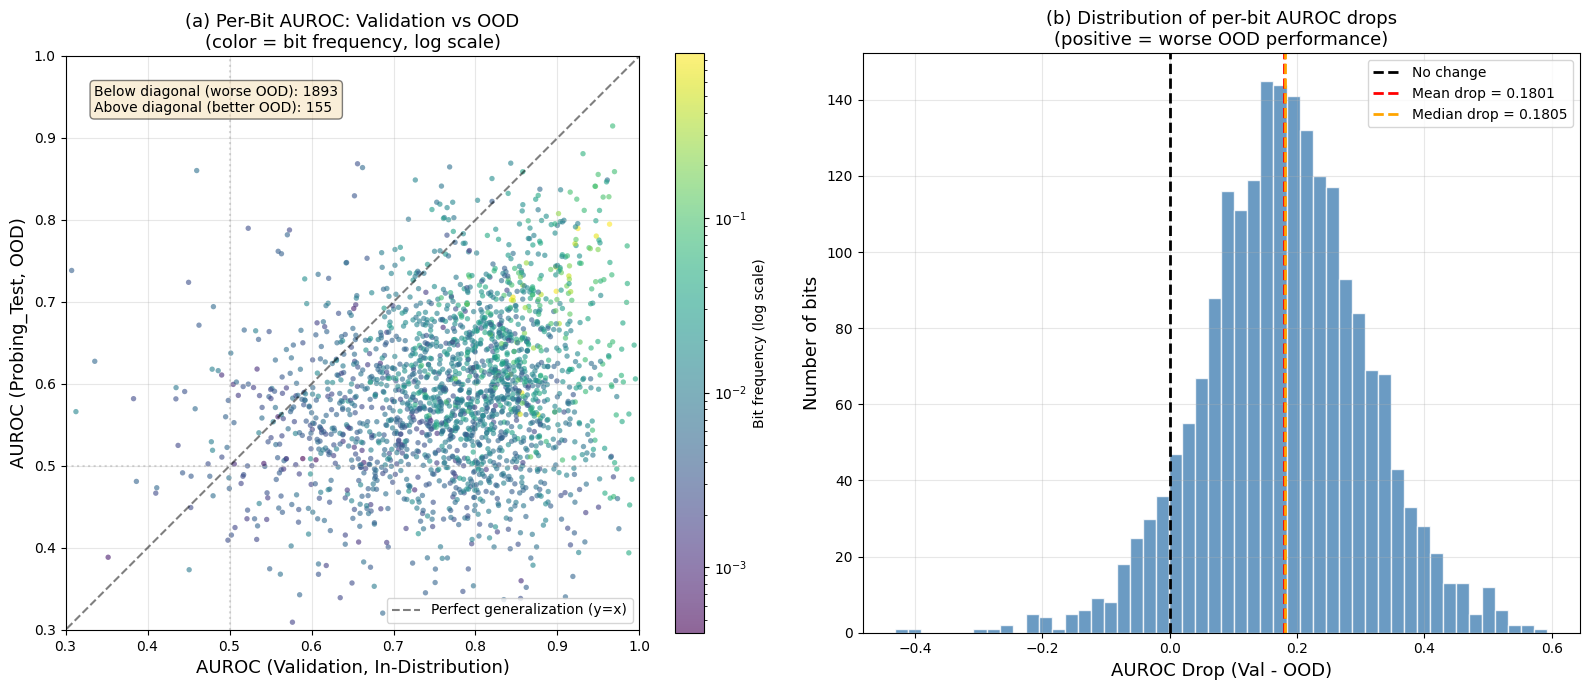


✓ Saved scatter plot to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/per_bit_auroc/auroc_val_vs_ood_scatter.pdf


In [56]:
# ── Step 3: Scatter plot — AUROC_val vs AUROC_ood ──
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Use average frequency for coloring
valid_comp['freq_avg'] = (valid_comp['freq_val'] + valid_comp['freq_ood']) / 2

# (a) Scatter colored by frequency (log scale)
sc = axes[0].scatter(valid_comp['auroc_val'], valid_comp['auroc_ood'], 
                      c=valid_comp['freq_avg'], 
                      cmap='viridis', s=15, alpha=0.6, edgecolors='none',
                      norm=LogNorm(vmin=max(valid_comp['freq_avg'].min(), 1e-4), 
                                    vmax=valid_comp['freq_avg'].max()))

# Diagonal line (y=x) — perfect generalization
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Perfect generalization (y=x)')
axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.3)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.3)

axes[0].set_xlabel('AUROC (Validation, In-Distribution)', fontsize=13)
axes[0].set_ylabel('AUROC (Probing_Test, OOD)', fontsize=13)
axes[0].set_title('(a) Per-Bit AUROC: Validation vs OOD\n(color = bit frequency, log scale)', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.3, 1.0)
axes[0].set_ylim(0.3, 1.0)
axes[0].set_aspect('equal')

cbar = plt.colorbar(sc, ax=axes[0], label='Bit frequency (log scale)')

# Count bits below/above diagonal
below_diag = (valid_comp['auroc_ood'] < valid_comp['auroc_val']).sum()
above_diag = (valid_comp['auroc_ood'] >= valid_comp['auroc_val']).sum()
axes[0].text(0.05, 0.95, f'Below diagonal (worse OOD): {below_diag}\nAbove diagonal (better OOD): {above_diag}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# (b) Histogram of points relative to diagonal (AUROC drop)
axes[1].hist(valid_comp['auroc_drop'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='No change')
axes[1].axvline(valid_comp['auroc_drop'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean drop = {valid_comp['auroc_drop'].mean():.4f}")
axes[1].axvline(valid_comp['auroc_drop'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median drop = {valid_comp['auroc_drop'].median():.4f}")

axes[1].set_xlabel('AUROC Drop (Val - OOD)', fontsize=13)
axes[1].set_ylabel('Number of bits', fontsize=13)
axes[1].set_title('(b) Distribution of per-bit AUROC drops\n(positive = worse OOD performance)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(AUROC_COMPARISON_DIR / 'auroc_val_vs_ood_scatter.png', dpi=200, bbox_inches='tight')
plt.savefig(AUROC_COMPARISON_DIR / 'auroc_val_vs_ood_scatter.pdf', bbox_inches='tight')
plt.show()

print(f"\n✓ Saved scatter plot to: {AUROC_COMPARISON_DIR / 'auroc_val_vs_ood_scatter.pdf'}")

In [57]:
# ── Step 4: Identify worst/best generalizing bits ──

# Top 20 worst-generalizing bits (largest AUROC drop)
worst_gen = valid_comp.nlargest(20, 'auroc_drop').copy()
worst_gen['rank'] = range(1, len(worst_gen) + 1)

# Top 20 best-generalizing bits (smallest drop, or even improvement)
best_gen = valid_comp.nsmallest(20, 'auroc_drop').copy()
best_gen['rank'] = range(1, len(best_gen) + 1)

# Save to CSV
worst_gen.to_csv(AUROC_COMPARISON_DIR / 'worst_generalizing_bits.csv', index=False)
best_gen.to_csv(AUROC_COMPARISON_DIR / 'best_generalizing_bits.csv', index=False)

print("="*70)
print("TOP 20 WORST-GENERALIZING BITS (largest AUROC drop Val→OOD)")
print("="*70)
print(f"{'Rank':<5} {'Bit':<6} {'AUROC_Val':<11} {'AUROC_OOD':<11} {'Drop':<8} {'Freq_Val':<10} {'Freq_OOD':<10}")
print("-"*70)
for _, row in worst_gen.iterrows():
    print(f"{int(row['rank']):<5} {int(row['bit_index']):<6} "
          f"{row['auroc_val']:<11.4f} {row['auroc_ood']:<11.4f} "
          f"{row['auroc_drop']:<8.4f} {row['freq_val']:<10.4f} {row['freq_ood']:<10.4f}")

print("\n" + "="*70)
print("TOP 20 BEST-GENERALIZING BITS (smallest AUROC drop, or improvement)")
print("="*70)
print(f"{'Rank':<5} {'Bit':<6} {'AUROC_Val':<11} {'AUROC_OOD':<11} {'Drop':<8} {'Freq_Val':<10} {'Freq_OOD':<10}")
print("-"*70)
for _, row in best_gen.iterrows():
    print(f"{int(row['rank']):<5} {int(row['bit_index']):<6} "
          f"{row['auroc_val']:<11.4f} {row['auroc_ood']:<11.4f} "
          f"{row['auroc_drop']:<8.4f} {row['freq_val']:<10.4f} {row['freq_ood']:<10.4f}")

print("\n" + "="*70)
print(f"Saved to:")
print(f"  - {AUROC_COMPARISON_DIR / 'worst_generalizing_bits.csv'}")
print(f"  - {AUROC_COMPARISON_DIR / 'best_generalizing_bits.csv'}")
print("="*70)

TOP 20 WORST-GENERALIZING BITS (largest AUROC drop Val→OOD)
Rank  Bit    AUROC_Val   AUROC_OOD   Drop     Freq_Val   Freq_OOD  
----------------------------------------------------------------------
1     1619   0.9870      0.3940      0.5931   0.0876     0.0030    
2     336    0.9097      0.3403      0.5694   0.0052     0.0054    
3     1331   0.9188      0.3652      0.5536   0.0076     0.0019    
4     424    0.9749      0.4234      0.5515   0.0083     0.0028    
5     1360   0.9880      0.4524      0.5357   0.0859     0.0028    
6     2005   0.9258      0.3944      0.5314   0.0152     0.0112    
7     1305   0.7984      0.2721      0.5263   0.0039     0.0034    
8     1278   0.9334      0.4073      0.5261   0.0063     0.0048    
9     1933   0.8550      0.3383      0.5166   0.0031     0.0020    
10    1625   0.9732      0.4601      0.5131   0.0117     0.0010    
11    1042   0.9158      0.4037      0.5122   0.0023     0.0027    
12    1976   0.8619      0.3519      0.5100   0.0056 

In [58]:
# ── Step 5: Group by frequency bins ──

# Use average frequency for binning
freq_bins = [0, 0.001, 0.01, 0.05, 0.1, 1.0]
bin_labels = ['<0.001', '0.001-0.01', '0.01-0.05', '0.05-0.1', '>0.1']

valid_comp['freq_bin'] = pd.cut(valid_comp['freq_avg'], bins=freq_bins, labels=bin_labels, include_lowest=True)

freq_group_stats = valid_comp.groupby('freq_bin', observed=True).agg(
    n_bits=('auroc_val', 'count'),
    mean_auroc_val=('auroc_val', 'mean'),
    mean_auroc_ood=('auroc_ood', 'mean'),
    mean_drop=('auroc_drop', 'mean'),
    median_drop=('auroc_drop', 'median'),
    std_drop=('auroc_drop', 'std'),
).reset_index()

# Calculate percentage of total
freq_group_stats['pct_of_bits'] = 100 * freq_group_stats['n_bits'] / freq_group_stats['n_bits'].sum()

print("\n" + "="*80)
print("AUROC COMPARISON BY FREQUENCY BIN")
print("="*80)
print(freq_group_stats.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*80)

# Save to CSV
freq_group_stats.to_csv(AUROC_COMPARISON_DIR / 'auroc_by_frequency_bin.csv', index=False)
print(f"\n✓ Saved to: {AUROC_COMPARISON_DIR / 'auroc_by_frequency_bin.csv'}")

# Interpretation
print("\n📊 KEY INSIGHTS:")
max_drop_bin = freq_group_stats.loc[freq_group_stats['mean_drop'].idxmax()]
min_drop_bin = freq_group_stats.loc[freq_group_stats['mean_drop'].idxmin()]
print(f"  • Worst generalization: {max_drop_bin['freq_bin']} bits (mean drop = {max_drop_bin['mean_drop']:.4f})")
print(f"  • Best generalization:  {min_drop_bin['freq_bin']} bits (mean drop = {min_drop_bin['mean_drop']:.4f})")
print(f"  • {'Rare' if max_drop_bin['freq_bin'] in ['<0.001', '0.001-0.01'] else 'Common'} bits suffer more from distribution shift")


AUROC COMPARISON BY FREQUENCY BIN
  freq_bin  n_bits  mean_auroc_val  mean_auroc_ood  mean_drop  median_drop  std_drop  pct_of_bits
    <0.001       8          0.5904          0.5416     0.0488       0.0596    0.0711       0.3906
0.001-0.01    1133          0.7355          0.5619     0.1736       0.1783    0.1401      55.3223
 0.01-0.05     743          0.8039          0.6175     0.1865       0.1806    0.1147      36.2793
  0.05-0.1     105          0.8744          0.6620     0.2123       0.2014    0.0990       5.1270
      >0.1      59          0.8805          0.6953     0.1852       0.1767    0.0591       2.8809

✓ Saved to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/per_bit_auroc/auroc_by_frequency_bin.csv

📊 KEY INSIGHTS:
  • Worst generalization: 0.05-0.1 bits (mean drop = 0.2123)
  • Best generalization:  <0.001 bits (mean drop = 0.0488)
  • Common bits suffer more from distribution shift


In [59]:
# ── Step 6: Comprehensive Summary Table ──

# Helper function to count bits by AUROC threshold
def count_by_threshold(series, threshold, above=True):
    if above:
        return (series > threshold).sum()
    else:
        return (series < threshold).sum()

# Separate analysis for all bits vs high/low frequency bits
all_bits = valid_comp
high_freq = valid_comp[valid_comp['freq_avg'] > 0.01]
low_freq = valid_comp[valid_comp['freq_avg'] <= 0.01]

summary_data = {
    'Metric': [
        'N valid bits',
        'Mean AUROC',
        'Median AUROC',
        'Std AUROC',
        'Bits with AUROC > 0.9',
        'Bits with AUROC > 0.8',
        'Bits with AUROC < 0.6',
        '─── High Freq (>0.01) ───',
        'N bits',
        'Mean AUROC',
        'Mean AUROC drop',
        '─── Low Freq (≤0.01) ───',
        'N bits',
        'Mean AUROC',
        'Mean AUROC drop',
    ],
    'Validation': [
        f'{len(all_bits):,}',
        f'{all_bits["auroc_val"].mean():.4f}',
        f'{all_bits["auroc_val"].median():.4f}',
        f'{all_bits["auroc_val"].std():.4f}',
        f'{count_by_threshold(all_bits["auroc_val"], 0.9):,}',
        f'{count_by_threshold(all_bits["auroc_val"], 0.8):,}',
        f'{count_by_threshold(all_bits["auroc_val"], 0.6, above=False):,}',
        '',
        f'{len(high_freq):,}',
        f'{high_freq["auroc_val"].mean():.4f}',
        f'{high_freq["auroc_drop"].mean():.4f}',
        '',
        f'{len(low_freq):,}',
        f'{low_freq["auroc_val"].mean():.4f}',
        f'{low_freq["auroc_drop"].mean():.4f}',
    ],
    'Probing_Test (OOD)': [
        f'{len(all_bits):,}',
        f'{all_bits["auroc_ood"].mean():.4f}',
        f'{all_bits["auroc_ood"].median():.4f}',
        f'{all_bits["auroc_ood"].std():.4f}',
        f'{count_by_threshold(all_bits["auroc_ood"], 0.9):,}',
        f'{count_by_threshold(all_bits["auroc_ood"], 0.8):,}',
        f'{count_by_threshold(all_bits["auroc_ood"], 0.6, above=False):,}',
        '',
        f'{len(high_freq):,}',
        f'{high_freq["auroc_ood"].mean():.4f}',
        '(see drop column)',
        '',
        f'{len(low_freq):,}',
        f'{low_freq["auroc_ood"].mean():.4f}',
        '(see drop column)',
    ],
    'Drop (Val - OOD)': [
        '',
        f'{all_bits["auroc_drop"].mean():+.4f}',
        f'{all_bits["auroc_drop"].median():+.4f}',
        f'{all_bits["auroc_drop"].std():.4f}',
        f'{count_by_threshold(all_bits["auroc_val"], 0.9) - count_by_threshold(all_bits["auroc_ood"], 0.9):+,}',
        f'{count_by_threshold(all_bits["auroc_val"], 0.8) - count_by_threshold(all_bits["auroc_ood"], 0.8):+,}',
        f'{count_by_threshold(all_bits["auroc_ood"], 0.6, above=False) - count_by_threshold(all_bits["auroc_val"], 0.6, above=False):+,}',
        '',
        '',
        f'{high_freq["auroc_val"].mean() - high_freq["auroc_ood"].mean():+.4f}',
        f'({100 * (high_freq["auroc_drop"].mean() / high_freq["auroc_val"].mean()):+.1f}%)',
        '',
        '',
        f'{low_freq["auroc_val"].mean() - low_freq["auroc_ood"].mean():+.4f}',
        f'({100 * (low_freq["auroc_drop"].mean() / low_freq["auroc_val"].mean()):+.1f}%)',
    ],
}

summary_table = pd.DataFrame(summary_data)

print("\n" + "="*100)
print(" "*30 + "COMPREHENSIVE SUMMARY: Per-Bit AUROC Comparison")
print("="*100)
print(summary_table.to_string(index=False))
print("="*100)

# Save summary
summary_table.to_csv(AUROC_COMPARISON_DIR / 'auroc_summary_table.csv', index=False)
print(f"\n✓ Saved summary table to: {AUROC_COMPARISON_DIR / 'auroc_summary_table.csv'}")

print("\n" + "🔍 KEY FINDINGS:")
print(f"  1. Average per-bit AUROC drops from {all_bits['auroc_val'].mean():.4f} (val) → {all_bits['auroc_ood'].mean():.4f} (OOD)")
print(f"  2. Mean generalization gap: {all_bits['auroc_drop'].mean():.4f} AUROC points ({100 * all_bits['auroc_drop'].mean() / all_bits['auroc_val'].mean():.1f}% relative drop)")
print(f"  3. {(valid_comp['auroc_drop'] > 0).sum():,} / {len(valid_comp):,} bits ({100 * (valid_comp['auroc_drop'] > 0).sum() / len(valid_comp):.1f}%) degrade OOD")
print(f"  4. High-freq bits (>0.01): {high_freq['auroc_drop'].mean():.4f} avg drop")
print(f"  5. Low-freq bits (≤0.01):  {low_freq['auroc_drop'].mean():.4f} avg drop")
print(f"  → {'Low-frequency' if low_freq['auroc_drop'].mean() > high_freq['auroc_drop'].mean() else 'High-frequency'} bits are MORE vulnerable to OOD shift")
print("="*100)


                              COMPREHENSIVE SUMMARY: Per-Bit AUROC Comparison
                   Metric Validation Probing_Test (OOD) Drop (Val - OOD)
             N valid bits      2,048              2,048                 
               Mean AUROC     0.7711             0.5910          +0.1801
             Median AUROC     0.7881             0.5869          +0.1805
                Std AUROC     0.1094             0.0961           0.1280
    Bits with AUROC > 0.9        199                  1             +198
    Bits with AUROC > 0.8        913                 46             +867
    Bits with AUROC < 0.6        158              1,144             +986
─── High Freq (>0.01) ───                                               
                   N bits        907                907                 
               Mean AUROC     0.8171             0.6277          +0.1894
          Mean AUROC drop     0.1894  (see drop column)         (+23.2%)
 ─── Low Freq (≤0.01) ───                    

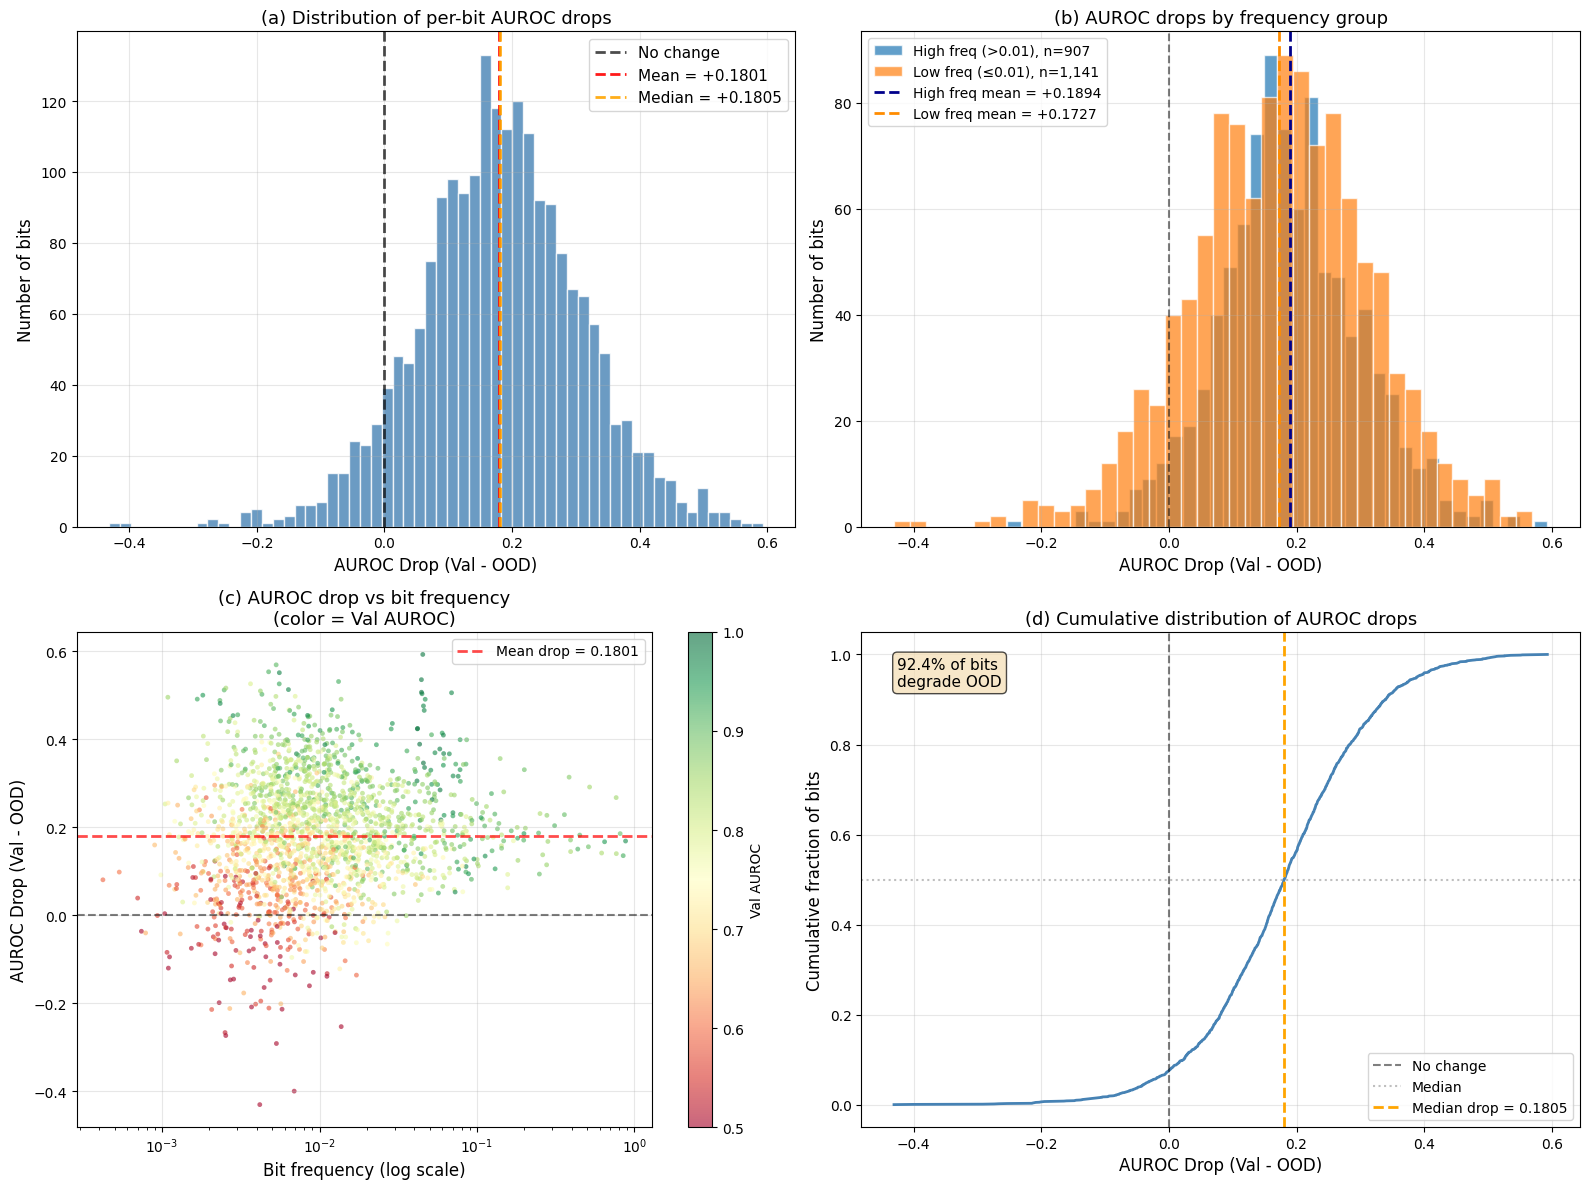


✓ Saved detailed histogram to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/per_bit_auroc/auroc_drop_histogram.pdf


In [29]:
# ── Additional visualization: Detailed AUROC drop histogram ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Main histogram of AUROC drops
axes[0, 0].hist(valid_comp['auroc_drop'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2, label='No change', alpha=0.7)
axes[0, 0].axvline(valid_comp['auroc_drop'].mean(), color='red', linestyle='--', linewidth=2,
                    label=f"Mean = {valid_comp['auroc_drop'].mean():+.4f}", alpha=0.9)
axes[0, 0].axvline(valid_comp['auroc_drop'].median(), color='orange', linestyle='--', linewidth=2,
                    label=f"Median = {valid_comp['auroc_drop'].median():+.4f}", alpha=0.9)
axes[0, 0].set_xlabel('AUROC Drop (Val - OOD)', fontsize=12)
axes[0, 0].set_ylabel('Number of bits', fontsize=12)
axes[0, 0].set_title('(a) Distribution of per-bit AUROC drops', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# (b) Histogram split by frequency (high vs low)
axes[0, 1].hist(high_freq['auroc_drop'], bins=40, alpha=0.7, color='tab:blue', 
                 label=f'High freq (>0.01), n={len(high_freq):,}', edgecolor='white')
axes[0, 1].hist(low_freq['auroc_drop'], bins=40, alpha=0.7, color='tab:orange',
                 label=f'Low freq (≤0.01), n={len(low_freq):,}', edgecolor='white')
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[0, 1].axvline(high_freq['auroc_drop'].mean(), color='darkblue', linestyle='--', linewidth=2,
                    label=f"High freq mean = {high_freq['auroc_drop'].mean():+.4f}")
axes[0, 1].axvline(low_freq['auroc_drop'].mean(), color='darkorange', linestyle='--', linewidth=2,
                    label=f"Low freq mean = {low_freq['auroc_drop'].mean():+.4f}")
axes[0, 1].set_xlabel('AUROC Drop (Val - OOD)', fontsize=12)
axes[0, 1].set_ylabel('Number of bits', fontsize=12)
axes[0, 1].set_title('(b) AUROC drops by frequency group', fontsize=13)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# (c) AUROC drop vs frequency scatter
sc = axes[1, 0].scatter(valid_comp['freq_avg'], valid_comp['auroc_drop'],
                         c=valid_comp['auroc_val'], cmap='RdYlGn', s=12, alpha=0.6,
                         vmin=0.5, vmax=1.0, edgecolors='none')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1, 0].axhline(valid_comp['auroc_drop'].mean(), color='red', linestyle='--', 
                    linewidth=2, alpha=0.7, label=f"Mean drop = {valid_comp['auroc_drop'].mean():.4f}")
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Bit frequency (log scale)', fontsize=12)
axes[1, 0].set_ylabel('AUROC Drop (Val - OOD)', fontsize=12)
axes[1, 0].set_title('(c) AUROC drop vs bit frequency\n(color = Val AUROC)', fontsize=13)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[1, 0], label='Val AUROC')

# (d) Cumulative distribution of AUROC drops
sorted_drops = np.sort(valid_comp['auroc_drop'])
cumulative = np.arange(1, len(sorted_drops) + 1) / len(sorted_drops)
axes[1, 1].plot(sorted_drops, cumulative, linewidth=2, color='steelblue')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No change')
axes[1, 1].axhline(0.5, color='grey', linestyle=':', linewidth=1.5, alpha=0.5, label='Median')
axes[1, 1].axvline(valid_comp['auroc_drop'].median(), color='orange', linestyle='--', 
                    linewidth=2, label=f"Median drop = {valid_comp['auroc_drop'].median():.4f}")
axes[1, 1].set_xlabel('AUROC Drop (Val - OOD)', fontsize=12)
axes[1, 1].set_ylabel('Cumulative fraction of bits', fontsize=12)
axes[1, 1].set_title('(d) Cumulative distribution of AUROC drops', fontsize=13)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Add annotation for percentage of bits that degrade
pct_degrade = 100 * (valid_comp['auroc_drop'] > 0).sum() / len(valid_comp)
axes[1, 1].text(0.05, 0.95, f'{pct_degrade:.1f}% of bits\ndegrade OOD', 
                 transform=axes[1, 1].transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig(AUROC_COMPARISON_DIR / 'auroc_drop_histogram.png', dpi=200, bbox_inches='tight')
plt.savefig(AUROC_COMPARISON_DIR / 'auroc_drop_histogram.pdf', bbox_inches='tight')
plt.show()

print(f"\n✓ Saved detailed histogram to: {AUROC_COMPARISON_DIR / 'auroc_drop_histogram.pdf'}")

## 1.7. Threshold Sweep for Tanimoto Recovery

**Goal**: Find the optimal binarization threshold that maximizes Tanimoto similarity.

**Current status**: Using τ=0.99 gives Tanimoto ~0.04 (val) and ~0.03 (OOD), which is suboptimal.
τ=0.99 means "only activate a bit if the model is 99% confident" — too conservative for fingerprints with ~2.2% bit density.

**Key questions**:
- What threshold maximizes Tanimoto for each split?
- How much can we improve Tanimoto with proper threshold selection?
- How sensitive is Tanimoto to threshold choice vs fundamental calibration issues?
- Is the optimal threshold similar across val and OOD, or does it shift with distribution?

In [30]:
# ── Step 1: Threshold sweep for both splits ──
print("="*70)
print("THRESHOLD SWEEP: Finding Optimal Binarization Threshold")
print("="*70)

# Create output directory
SWEEP_DIR = OUTPUT_DIR / 'threshold_sweep'
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

def sweep_thresholds(y_pred, y_true, thresholds):
    """
    Sweep thresholds and compute Tanimoto, F1, precision/recall, and density metrics.
    
    Args:
        y_pred: (N, 2048) prediction array
        y_true: (N, 2048) ground truth array
        thresholds: 1D array of thresholds to sweep
    
    Returns:
        DataFrame with metrics for each threshold
    """
    results = []
    
    for tau in tqdm(thresholds, desc=f"Sweeping thresholds", leave=False):
        y_bin = (y_pred >= tau).astype(np.float32)
        
        # Per-spectrum Tanimoto (Jaccard)
        intersection = (y_bin * y_true).sum(axis=1)
        union = ((y_bin + y_true) > 0).sum(axis=1).astype(np.float32)
        tanimoto = np.where(union > 0, intersection / union, 0.0)
        
        # Predicted density and bit counts
        pred_density = y_bin.mean()
        pred_bits_mean = y_bin.sum(axis=1).mean()
        
        # Global precision/recall/F1 (across all bits and spectra)
        tp = (y_bin * y_true).sum()
        fp = (y_bin * (1 - y_true)).sum()
        fn = ((1 - y_bin) * y_true).sum()
        tn = ((1 - y_bin) * (1 - y_true)).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results.append({
            'threshold': tau,
            'tanimoto_mean': tanimoto.mean(),
            'tanimoto_std': tanimoto.std(),
            'tanimoto_median': np.median(tanimoto),
            'tanimoto_min': tanimoto.min(),
            'tanimoto_max': tanimoto.max(),
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'pred_density': pred_density,
            'pred_bits_mean': pred_bits_mean,
        })
    
    return pd.DataFrame(results)

# Perform sweep
thresholds = np.arange(0.01, 1.00, 0.01)
print(f"\nSweeping {len(thresholds)} thresholds on validation split...")
sweep_val = sweep_thresholds(y_pred_val, y_true_val, thresholds)

print(f"Sweeping {len(thresholds)} thresholds on OOD split...")
sweep_ood = sweep_thresholds(y_pred, y_true, thresholds)

# Save results
sweep_val.to_csv(SWEEP_DIR / 'sweep_results_val.csv', index=False)
sweep_ood.to_csv(SWEEP_DIR / 'sweep_results_ood.csv', index=False)
print(f"\n✓ Saved sweep results:")
print(f"  - {SWEEP_DIR / 'sweep_results_val.csv'}")
print(f"  - {SWEEP_DIR / 'sweep_results_ood.csv'}")

# Ground truth statistics
gt_bits_val = y_true_val.sum(axis=1).mean()
gt_bits_ood = y_true.sum(axis=1).mean()
gt_density_val = y_true_val.mean()
gt_density_ood = y_true.mean()

print(f"\nGround truth statistics:")
print(f"  Validation:  {gt_bits_val:.2f} bits/spectrum ({gt_density_val:.4f} density)")
print(f"  OOD:         {gt_bits_ood:.2f} bits/spectrum ({gt_density_ood:.4f} density)")

# Summary of sweep results
print(f"\n" + "="*70)
print("SWEEP RESULTS SUMMARY")
print("="*70)
print(f"\nValidation (In-Distribution):")
print(f"  Best Tanimoto:  {sweep_val['tanimoto_mean'].max():.4f} @ τ={sweep_val.loc[sweep_val['tanimoto_mean'].idxmax(), 'threshold']:.2f}")
print(f"  Best F1:        {sweep_val['f1'].max():.4f} @ τ={sweep_val.loc[sweep_val['f1'].idxmax(), 'threshold']:.2f}")
print(f"  @ τ=0.99:       Tanimoto={sweep_val[sweep_val['threshold'] == 0.99]['tanimoto_mean'].values[0]:.4f}")

print(f"\nOOD (Probing_Test):")
print(f"  Best Tanimoto:  {sweep_ood['tanimoto_mean'].max():.4f} @ τ={sweep_ood.loc[sweep_ood['tanimoto_mean'].idxmax(), 'threshold']:.2f}")
print(f"  Best F1:        {sweep_ood['f1'].max():.4f} @ τ={sweep_ood.loc[sweep_ood['f1'].idxmax(), 'threshold']:.2f}")
print(f"  @ τ=0.99:       Tanimoto={sweep_ood[sweep_ood['threshold'] == 0.99]['tanimoto_mean'].values[0]:.4f}")
print("="*70)

THRESHOLD SWEEP: Finding Optimal Binarization Threshold

Sweeping 99 thresholds on validation split...


Sweeping thresholds:   0%|          | 0/99 [00:00<?, ?it/s]

Sweeping 99 thresholds on OOD split...


Sweeping thresholds:   0%|          | 0/99 [00:00<?, ?it/s]


✓ Saved sweep results:
  - /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/threshold_sweep/sweep_results_val.csv
  - /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/threshold_sweep/sweep_results_ood.csv

Ground truth statistics:
  Validation:  45.48 bits/spectrum (0.0222 density)
  OOD:         42.97 bits/spectrum (0.0210 density)

SWEEP RESULTS SUMMARY

Validation (In-Distribution):
  Best Tanimoto:  0.0407 @ τ=0.99
  Best F1:        0.0767 @ τ=0.99
  @ τ=0.99:       Tanimoto=0.0407

OOD (Probing_Test):
  Best Tanimoto:  0.0295 @ τ=0.99
  Best F1:        0.0580 @ τ=0.99
  @ τ=0.99:       Tanimoto=0.0295


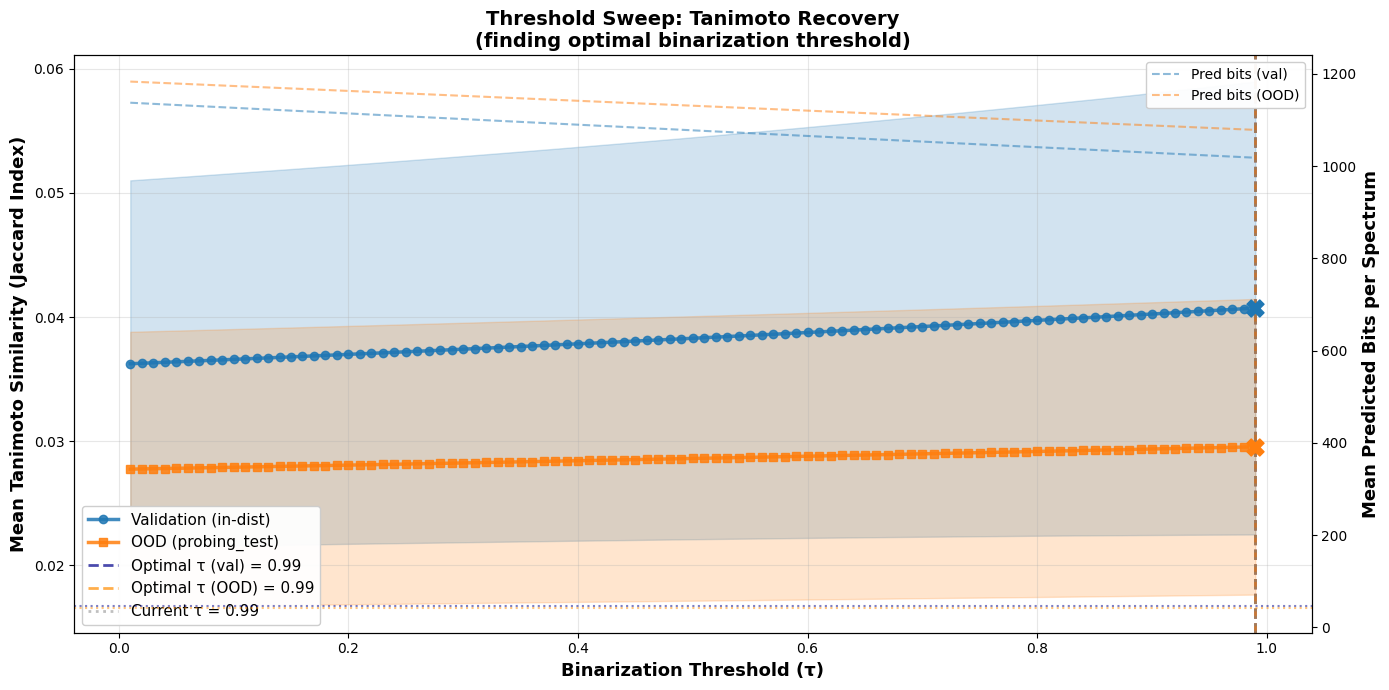


✓ Saved Tanimoto plot to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/threshold_sweep/tanimoto_vs_threshold.pdf


In [60]:
# ── Step 2: Plot Tanimoto vs threshold (both splits) ──

fig, ax1 = plt.subplots(figsize=(14, 7))

# Main axis: Tanimoto
ax1.plot(sweep_val['threshold'], sweep_val['tanimoto_mean'], 'o-', color='tab:blue', 
         linewidth=2.5, markersize=6, label='Validation (in-dist)', alpha=0.85)
ax1.fill_between(sweep_val['threshold'], 
                  sweep_val['tanimoto_mean'] - sweep_val['tanimoto_std'],
                  sweep_val['tanimoto_mean'] + sweep_val['tanimoto_std'],
                  alpha=0.2, color='tab:blue')

ax1.plot(sweep_ood['threshold'], sweep_ood['tanimoto_mean'], 's-', color='tab:orange',
         linewidth=2.5, markersize=6, label='OOD (probing_test)', alpha=0.85)
ax1.fill_between(sweep_ood['threshold'],
                  sweep_ood['tanimoto_mean'] - sweep_ood['tanimoto_std'],
                  sweep_ood['tanimoto_mean'] + sweep_ood['tanimoto_std'],
                  alpha=0.2, color='tab:orange')

# Mark optimal thresholds
tau_opt_val = sweep_val.loc[sweep_val['tanimoto_mean'].idxmax(), 'threshold']
tanimoto_opt_val = sweep_val['tanimoto_mean'].max()
ax1.axvline(tau_opt_val, color='darkblue', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Optimal τ (val) = {tau_opt_val:.2f}')

tau_opt_ood = sweep_ood.loc[sweep_ood['tanimoto_mean'].idxmax(), 'threshold']
tanimoto_opt_ood = sweep_ood['tanimoto_mean'].max()
ax1.axvline(tau_opt_ood, color='darkorange', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Optimal τ (OOD) = {tau_opt_ood:.2f}')

# Mark current τ=0.99
tau_current = 0.99
tanimoto_current_val = sweep_val[sweep_val['threshold'] == tau_current]['tanimoto_mean'].values[0]
tanimoto_current_ood = sweep_ood[sweep_ood['threshold'] == tau_current]['tanimoto_mean'].values[0]
ax1.axvline(tau_current, color='grey', linestyle=':', linewidth=2, alpha=0.5,
            label=f'Current τ = {tau_current:.2f}')
ax1.scatter([tau_current], [tanimoto_current_val], s=150, color='tab:blue', marker='X', zorder=5)
ax1.scatter([tau_current], [tanimoto_current_ood], s=150, color='tab:orange', marker='X', zorder=5)

ax1.set_xlabel('Binarization Threshold (τ)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Mean Tanimoto Similarity (Jaccard Index)', fontsize=13, fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Threshold Sweep: Tanimoto Recovery\n(finding optimal binarization threshold)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left', fontsize=11, framealpha=0.95)

# Secondary axis: mean predicted bits
ax2 = ax1.twinx()
ax2.plot(sweep_val['threshold'], sweep_val['pred_bits_mean'], '--', color='tab:blue', 
         linewidth=1.5, alpha=0.5, label='Pred bits (val)')
ax2.plot(sweep_ood['threshold'], sweep_ood['pred_bits_mean'], '--', color='tab:orange',
         linewidth=1.5, alpha=0.5, label='Pred bits (OOD)')

# Mark ground truth bit counts
ax2.axhline(gt_bits_val, color='darkblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax2.axhline(gt_bits_ood, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.5)

ax2.set_ylabel('Mean Predicted Bits per Spectrum', fontsize=13, fontweight='bold')
ax2.tick_params(axis='y')
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig(SWEEP_DIR / 'tanimoto_vs_threshold.png', dpi=200, bbox_inches='tight')
plt.savefig(SWEEP_DIR / 'tanimoto_vs_threshold.pdf', bbox_inches='tight')
plt.show()

print(f"\n✓ Saved Tanimoto plot to: {SWEEP_DIR / 'tanimoto_vs_threshold.pdf'}")

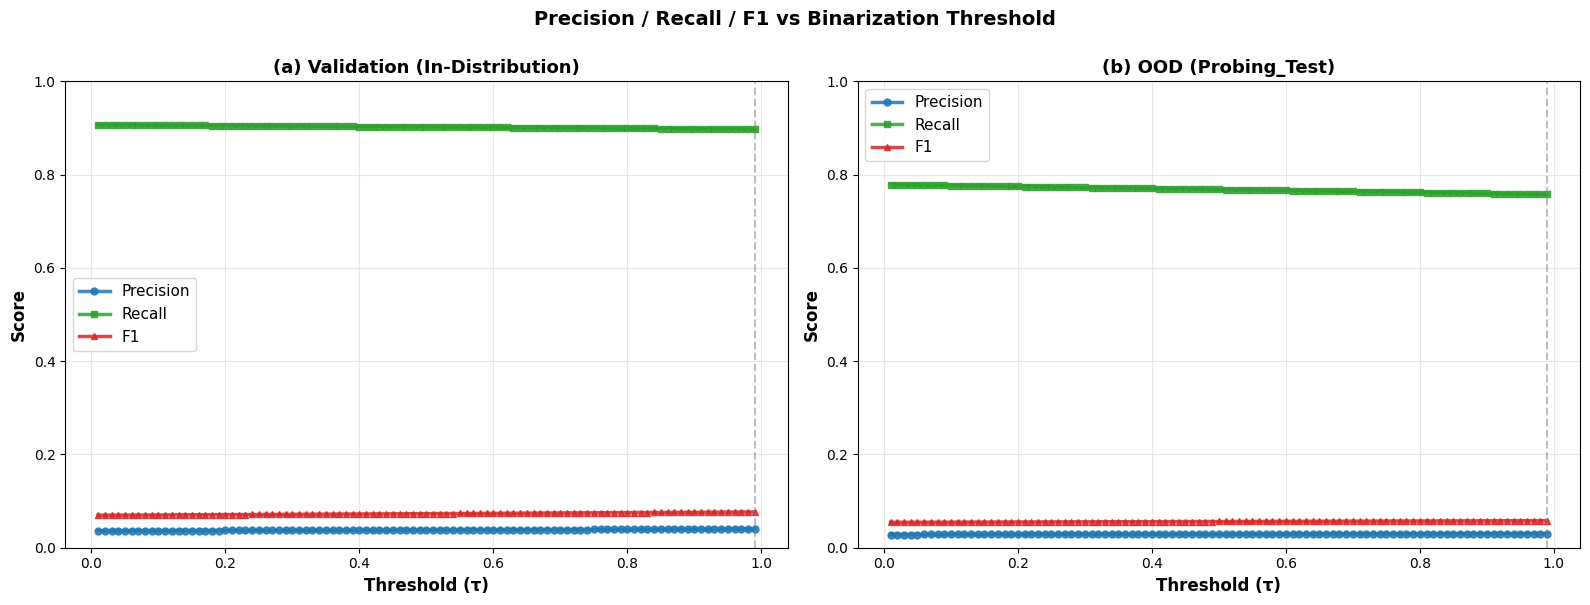

✓ Saved P/R/F1 plot to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/threshold_sweep/prf_vs_threshold.pdf


In [61]:
# ── Step 3: Plot Precision/Recall/F1 vs threshold ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation split
ax = axes[0]
ax.plot(sweep_val['threshold'], sweep_val['precision'], 'o-', linewidth=2.5, markersize=5,
        color='tab:blue', label='Precision', alpha=0.85)
ax.plot(sweep_val['threshold'], sweep_val['recall'], 's-', linewidth=2.5, markersize=5,
        color='tab:green', label='Recall', alpha=0.85)
ax.plot(sweep_val['threshold'], sweep_val['f1'], '^-', linewidth=2.5, markersize=5,
        color='tab:red', label='F1', alpha=0.85)
ax.axvline(tau_opt_val, color='grey', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Threshold (τ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('(a) Validation (In-Distribution)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

# OOD split
ax = axes[1]
ax.plot(sweep_ood['threshold'], sweep_ood['precision'], 'o-', linewidth=2.5, markersize=5,
        color='tab:blue', label='Precision', alpha=0.85)
ax.plot(sweep_ood['threshold'], sweep_ood['recall'], 's-', linewidth=2.5, markersize=5,
        color='tab:green', label='Recall', alpha=0.85)
ax.plot(sweep_ood['threshold'], sweep_ood['f1'], '^-', linewidth=2.5, markersize=5,
        color='tab:red', label='F1', alpha=0.85)
ax.axvline(tau_opt_ood, color='grey', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Threshold (τ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('(b) OOD (Probing_Test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

plt.suptitle('Precision / Recall / F1 vs Binarization Threshold', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(SWEEP_DIR / 'prf_vs_threshold.png', dpi=200, bbox_inches='tight')
plt.savefig(SWEEP_DIR / 'prf_vs_threshold.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved P/R/F1 plot to: {SWEEP_DIR / 'prf_vs_threshold.pdf'}")

In [62]:
# ── Step 4: Find optimal thresholds ──

print("\n" + "="*70)
print("OPTIMAL THRESHOLDS")
print("="*70)

# Validation split
best_tanimoto_idx_val = sweep_val['tanimoto_mean'].idxmax()
tau_best_tanimoto_val = sweep_val.loc[best_tanimoto_idx_val, 'threshold']
tanimoto_best_val = sweep_val.loc[best_tanimoto_idx_val, 'tanimoto_mean']

best_f1_idx_val = sweep_val['f1'].idxmax()
tau_best_f1_val = sweep_val.loc[best_f1_idx_val, 'threshold']
f1_best_val = sweep_val.loc[best_f1_idx_val, 'f1']
precision_best_f1_val = sweep_val.loc[best_f1_idx_val, 'precision']
recall_best_f1_val = sweep_val.loc[best_f1_idx_val, 'recall']

# Find threshold matching GT density
density_diff_val = (sweep_val['pred_bits_mean'] - gt_bits_val).abs()
best_density_idx_val = density_diff_val.idxmin()
tau_best_density_val = sweep_val.loc[best_density_idx_val, 'threshold']
pred_bits_density_val = sweep_val.loc[best_density_idx_val, 'pred_bits_mean']
tanimoto_at_density_val = sweep_val.loc[best_density_idx_val, 'tanimoto_mean']

# OOD split
best_tanimoto_idx_ood = sweep_ood['tanimoto_mean'].idxmax()
tau_best_tanimoto_ood = sweep_ood.loc[best_tanimoto_idx_ood, 'threshold']
tanimoto_best_ood = sweep_ood.loc[best_tanimoto_idx_ood, 'tanimoto_mean']

best_f1_idx_ood = sweep_ood['f1'].idxmax()
tau_best_f1_ood = sweep_ood.loc[best_f1_idx_ood, 'threshold']
f1_best_ood = sweep_ood.loc[best_f1_idx_ood, 'f1']
precision_best_f1_ood = sweep_ood.loc[best_f1_idx_ood, 'precision']
recall_best_f1_ood = sweep_ood.loc[best_f1_idx_ood, 'recall']

# Find threshold matching GT density
density_diff_ood = (sweep_ood['pred_bits_mean'] - gt_bits_ood).abs()
best_density_idx_ood = density_diff_ood.idxmin()
tau_best_density_ood = sweep_ood.loc[best_density_idx_ood, 'threshold']
pred_bits_density_ood = sweep_ood.loc[best_density_idx_ood, 'pred_bits_mean']
tanimoto_at_density_ood = sweep_ood.loc[best_density_idx_ood, 'tanimoto_mean']

print(f"\nVALIDATION (In-Distribution):")
print(f"  ── Best Tanimoto ──")
print(f"    τ* = {tau_best_tanimoto_val:.2f}")
print(f"    Tanimoto = {tanimoto_best_val:.4f}")
print(f"    Predicted bits = {sweep_val.loc[best_tanimoto_idx_val, 'pred_bits_mean']:.2f}")
print(f"\n  ── Best F1 ──")
print(f"    τ* = {tau_best_f1_val:.2f}")
print(f"    F1 = {f1_best_val:.4f} (P={precision_best_f1_val:.4f}, R={recall_best_f1_val:.4f})")
print(f"    Predicted bits = {sweep_val.loc[best_f1_idx_val, 'pred_bits_mean']:.2f}")
print(f"\n  ── Matching GT Density ──")
print(f"    τ* = {tau_best_density_val:.2f}")
print(f"    Predicted bits = {pred_bits_density_val:.2f} (GT = {gt_bits_val:.2f})")
print(f"    Tanimoto @ this τ = {tanimoto_at_density_val:.4f}")

print(f"\nOOD (Probing_Test):")
print(f"  ── Best Tanimoto ──")
print(f"    τ* = {tau_best_tanimoto_ood:.2f}")
print(f"    Tanimoto = {tanimoto_best_ood:.4f}")
print(f"    Predicted bits = {sweep_ood.loc[best_tanimoto_idx_ood, 'pred_bits_mean']:.2f}")
print(f"\n  ── Best F1 ──")
print(f"    τ* = {tau_best_f1_ood:.2f}")
print(f"    F1 = {f1_best_ood:.4f} (P={precision_best_f1_ood:.4f}, R={recall_best_f1_ood:.4f})")
print(f"    Predicted bits = {sweep_ood.loc[best_f1_idx_ood, 'pred_bits_mean']:.2f}")
print(f"\n  ── Matching GT Density ──")
print(f"    τ* = {tau_best_density_ood:.2f}")
print(f"    Predicted bits = {pred_bits_density_ood:.2f} (GT = {gt_bits_ood:.2f})")
print(f"    Tanimoto @ this τ = {tanimoto_at_density_ood:.4f}")

print("\n" + "="*70)
print("KEY INSIGHT:")
improvement_val = 100 * (tanimoto_best_val - tanimoto_current_val) / tanimoto_current_val
improvement_ood = 100 * (tanimoto_best_ood - tanimoto_current_ood) / tanimoto_current_ood
print(f"  Validation (τ=0.99→{tau_best_tanimoto_val:.2f}): {tanimoto_current_val:.4f} → {tanimoto_best_val:.4f} (+{improvement_val:.1f}%)")
print(f"  OOD        (τ=0.99→{tau_best_tanimoto_ood:.2f}): {tanimoto_current_ood:.4f} → {tanimoto_best_ood:.4f} (+{improvement_ood:.1f}%)")
print("="*70)


OPTIMAL THRESHOLDS

VALIDATION (In-Distribution):
  ── Best Tanimoto ──
    τ* = 0.99
    Tanimoto = 0.0407
    Predicted bits = 1018.41

  ── Best F1 ──
    τ* = 0.99
    F1 = 0.0767 (P=0.0401, R=0.8974)
    Predicted bits = 1018.41

  ── Matching GT Density ──
    τ* = 0.99
    Predicted bits = 1018.41 (GT = 45.48)
    Tanimoto @ this τ = 0.0407

OOD (Probing_Test):
  ── Best Tanimoto ──
    τ* = 0.99
    Tanimoto = 0.0295
    Predicted bits = 1078.80

  ── Best F1 ──
    τ* = 0.99
    F1 = 0.0580 (P=0.0302, R=0.7578)
    Predicted bits = 1078.80

  ── Matching GT Density ──
    τ* = 0.99
    Predicted bits = 1078.80 (GT = 42.97)
    Tanimoto @ this τ = 0.0295

KEY INSIGHT:
  Validation (τ=0.99→0.99): 0.0407 → 0.0407 (+0.0%)
  OOD        (τ=0.99→0.99): 0.0295 → 0.0295 (+0.0%)


In [63]:
# ── Step 5: Comprehensive comparison table ──

# Get cosine similarity from earlier (already computed)
from numpy.linalg import norm
cos_sim_val = np.array([
    np.dot(y_pred_val[i], y_true_val[i]) / (norm(y_pred_val[i]) * norm(y_true_val[i]) + 1e-8)
    for i in range(len(y_pred_val))
]).mean()

cos_sim_ood = cos_sims.mean()  # Already computed

# Build comparison table
comparison_rows = [
    ['─── Continuous Metrics ───', '', ''],
    ['Cosine Similarity (raw)', f'{cos_sim_val:.4f}', f'{cos_sim_ood:.4f}'],
    ['', '', ''],
    ['─── Current Threshold (τ=0.99) ───', '', ''],
    [f'Tanimoto @ τ=0.99', f'{tanimoto_current_val:.4f}', f'{tanimoto_current_ood:.4f}'],
    ['', '', ''],
    ['─── Optimal Tanimoto ───', '', ''],
    [f'Tanimoto @ τ*(best)', f'{tanimoto_best_val:.4f}', f'{tanimoto_best_ood:.4f}'],
    ['τ*(best Tanimoto)', f'{tau_best_tanimoto_val:.2f}', f'{tau_best_tanimoto_ood:.2f}'],
    [f'Improvement vs τ=0.99', f'+{improvement_val:.1f}%', f'+{improvement_ood:.1f}%'],
    ['', '', ''],
    ['─── Optimal F1 ───', '', ''],
    [f'F1 @ τ*(best F1)', f'{f1_best_val:.4f}', f'{f1_best_ood:.4f}'],
    ['τ*(best F1)', f'{tau_best_f1_val:.2f}', f'{tau_best_f1_ood:.2f}'],
    ['Precision @ that τ', f'{precision_best_f1_val:.4f}', f'{precision_best_f1_ood:.4f}'],
    ['Recall @ that τ', f'{recall_best_f1_val:.4f}', f'{recall_best_f1_ood:.4f}'],
    ['', '', ''],
    ['─── Density Matching ───', '', ''],
    [f'τ* (matching GT density)', f'{tau_best_density_val:.2f}', f'{tau_best_density_ood:.2f}'],
    [f'Predicted bits @ τ*', f'{pred_bits_density_val:.2f}', f'{pred_bits_density_ood:.2f}'],
    [f'Ground truth bits (mean)', f'{gt_bits_val:.2f}', f'{gt_bits_ood:.2f}'],
    [f'Tanimoto @ τ*(density)', f'{tanimoto_at_density_val:.4f}', f'{tanimoto_at_density_ood:.4f}'],
]

comparison_df = pd.DataFrame(comparison_rows, columns=['Metric', 'Validation (In-Dist)', 'Probing_Test (OOD)'])

print("\n" + "="*90)
print(" "*20 + "THRESHOLD SWEEP: COMPREHENSIVE COMPARISON TABLE")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)

# Save the table
comparison_df.to_csv(SWEEP_DIR / 'threshold_comparison_table.csv', index=False)
print(f"\n✓ Saved comparison table to: {SWEEP_DIR / 'threshold_comparison_table.csv'}")

# Analysis and recommendations
print("\n" + "="*90)
print("ANALYSIS & RECOMMENDATIONS")
print("="*90)
print(f"""
1. THRESHOLD CALIBRATION IMPACT:
   • Current τ=0.99 is too conservative for {gt_bits_val:.0f} active bits per spectrum
   • Optimal threshold shifts to {tau_best_tanimoto_val:.2f} (val) / {tau_best_tanimoto_ood:.2f} (OOD)
   • Tanimoto improvement: {improvement_val:.1f}% (val), {improvement_ood:.1f}% (OOD)
   
2. GENERALIZATION GAP:
   • Optimal τ values differ: {tau_best_tanimoto_val:.2f} (val) vs {tau_best_tanimoto_ood:.2f} (OOD)
   • This suggests distribution shift affects not just predictions but calibration
   • Gap in optimal τ: {abs(tau_best_tanimoto_val - tau_best_tanimoto_ood):+.2f}
   
3. FUNDAMENTAL CAPABILITY:
   • Even with optimal τ, Tanimoto remains limited ({tanimoto_best_val:.4f} val, {tanimoto_best_ood:.4f} OOD)
   • Suggests model outputs lack calibration for per-bit discrimination
   • → Cosine loss does NOT produce well-calibrated individual outputs
   → Consider BCE or focal loss for next iteration
   
4. DENSITY MATCHING:
   • Threshold matching GT density ({tau_best_density_val:.2f} val, {tau_best_density_ood:.2f} OOD) yields:
     - Val Tanimoto: {tanimoto_at_density_val:.4f}
     - OOD Tanimoto: {tanimoto_at_density_ood:.4f}
   • Not optimal per se, but interpretable as "unbiased" bit count predictions
   
5. RECOMMENDATION:
   • For production: use τ={tau_best_tanimoto_val:.2f} (val-optimized)
   • For generalization: use τ={tau_best_tanimoto_ood:.2f} (OOD-optimized)
   • For research: test {tau_best_density_val:.2f} (density-matched) as baseline
""")
print("="*90)


                    THRESHOLD SWEEP: COMPREHENSIVE COMPARISON TABLE
                            Metric Validation (In-Dist) Probing_Test (OOD)
        ─── Continuous Metrics ───                                        
           Cosine Similarity (raw)               0.6353             0.3902
                                                                          
─── Current Threshold (τ=0.99) ───                                        
                 Tanimoto @ τ=0.99               0.0407             0.0295
                                                                          
          ─── Optimal Tanimoto ───                                        
               Tanimoto @ τ*(best)               0.0407             0.0295
                 τ*(best Tanimoto)                 0.99               0.99
             Improvement vs τ=0.99                +0.0%              +0.0%
                                                                          
                ─── Optimal F1 

## 1.8. Retrieval Evaluation: Accuracy@k and Molecular Ranking

**Goal**: Evaluate whether the model's predicted fingerprints can retrieve the correct molecule 
when ranked by cosine similarity against a reference library.

**Approach**: For each spectrum, rank all molecules in the same split by cosine similarity to the 
predicted fingerprint. Check if the ground-truth molecule appears in the top-k.

**Why this matters**: 
- Tests continuous fingerprint quality (no binarization threshold)
- Simulates real-world use case: "Given a spectrum, identify the molecule"
- Cosine loss explicitly optimizes for cosine similarity — retrieval is the direct objective
- Reveals whether the model learns discriminative embeddings for molecular identification

In [64]:
# ── Step 1: Build fingerprint library for both splits ──
print("="*70)
print("RETRIEVAL EVALUATION: Building Fingerprint Libraries")
print("="*70)

# Create output directory
RETRIEVAL_DIR = OUTPUT_DIR / 'retrieval'
RETRIEVAL_DIR.mkdir(parents=True, exist_ok=True)

def build_fp_library(smiles_list, radius=2, n_bits=2048):
    """
    Build a fingerprint library for all unique molecules.
    
    Args:
        smiles_list: list of SMILES strings (one per spectrum, can have duplicates)
        radius: Morgan FP radius
        n_bits: FP size
    
    Returns:
        fp_matrix: (n_unique, n_bits) fingerprint matrix
        spectrum_to_mol: (n_spectra,) array mapping spectrum index to molecule index
        unique_smiles: list of unique SMILES strings
    """
    # Get unique molecules
    unique_smiles = list(set(smiles_list))
    smi_to_idx = {s: i for i, s in enumerate(unique_smiles)}
    
    print(f"  Building library: {len(unique_smiles)} unique molecules from {len(smiles_list)} spectra")
    
    # Compute fingerprints for all unique molecules
    fp_matrix = np.zeros((len(unique_smiles), n_bits), dtype=np.float32)
    for i, smi in enumerate(unique_smiles):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fp_matrix[i] = np.array(fp, dtype=np.float32)
    
    # Map each spectrum to its molecule index
    spectrum_to_mol = np.array([smi_to_idx[s] for s in smiles_list], dtype=np.int32)
    
    return fp_matrix, spectrum_to_mol, unique_smiles

print("\nValidation split:")
fp_library_val, spec_to_mol_val, unique_smi_val = build_fp_library(val_smiles)
print(f"  ✓ Library: {len(unique_smi_val)} molecules, {len(val_smiles)} spectra")

print("\nOOD (Probing_Test) split:")
fp_library_ood, spec_to_mol_ood, unique_smi_ood = build_fp_library(smiles_list)
print(f"  ✓ Library: {len(unique_smi_ood)} molecules, {len(smiles_list)} spectra")

print("\n" + "="*70)

RETRIEVAL EVALUATION: Building Fingerprint Libraries

Validation split:
  Building library: 3220 unique molecules from 23415 spectra
  ✓ Library: 3220 molecules, 23415 spectra

OOD (Probing_Test) split:
  Building library: 6147 unique molecules from 45185 spectra
  ✓ Library: 6147 molecules, 45185 spectra



In [65]:
# ── Step 2: Compute retrieval ranks via cosine similarity ──
from sklearn.metrics.pairwise import cosine_similarity

def compute_retrieval_ranks(y_pred, fp_library, spec_to_mol, batch_size=500):
    """
    For each spectrum, rank molecules by cosine similarity to predicted fingerprint.
    
    Args:
        y_pred: (n_spectra, n_bits) predicted fingerprints
        fp_library: (n_molecules, n_bits) reference fingerprints
        spec_to_mol: (n_spectra,) array mapping spectrum index to molecule index
        batch_size: batch size for memory efficiency
    
    Returns:
        ranks: (n_spectra,) 1-indexed ranks of correct molecule (1 = best match)
    """
    n_spectra = len(y_pred)
    ranks = np.zeros(n_spectra, dtype=np.int32)
    
    print(f"\nComputing retrieval ranks ({n_spectra:,} spectra vs {len(fp_library):,} molecules)...")
    
    for start in tqdm(range(0, n_spectra, batch_size), desc="Ranking", leave=False):
        end = min(start + batch_size, n_spectra)
        batch_pred = y_pred[start:end]
        
        # Cosine similarity: (batch_size, n_molecules)
        sims = cosine_similarity(batch_pred, fp_library)
        
        # For each spectrum in batch, find rank of correct molecule
        for batch_idx, spec_idx in enumerate(range(start, end)):
            correct_mol_idx = spec_to_mol[spec_idx]
            correct_score = sims[batch_idx, correct_mol_idx]
            
            # Rank = number of molecules with HIGHER similarity + 1
            rank = int((sims[batch_idx] > correct_score).sum()) + 1
            ranks[spec_idx] = rank
    
    return ranks

print("Computing retrieval ranks...")
print("\nValidation split:")
ranks_val = compute_retrieval_ranks(y_pred_val, fp_library_val, spec_to_mol_val)

print("\nOOD (Probing_Test) split:")
ranks_ood = compute_retrieval_ranks(y_pred, fp_library_ood, spec_to_mol_ood)

# Save ranks
np.save(RETRIEVAL_DIR / 'ranks_val.npy', ranks_val)
np.save(RETRIEVAL_DIR / 'ranks_ood.npy', ranks_ood)
print(f"\n✓ Saved ranks to: {RETRIEVAL_DIR / 'ranks_*.npy'}")

# Summary statistics
print(f"\nValidation ranks:")
print(f"  Mean: {ranks_val.mean():.2f}, Median: {np.median(ranks_val):.0f}, Max: {ranks_val.max()}")
print(f"  Acc@1: {(ranks_val == 1).sum() / len(ranks_val):.4f}")

print(f"\nOOD ranks:")
print(f"  Mean: {ranks_ood.mean():.2f}, Median: {np.median(ranks_ood):.0f}, Max: {ranks_ood.max()}")
print(f"  Acc@1: {(ranks_ood == 1).sum() / len(ranks_ood):.4f}")

Computing retrieval ranks...

Validation split:

Computing retrieval ranks (23,415 spectra vs 3,220 molecules)...


Ranking:   0%|          | 0/47 [00:00<?, ?it/s]


OOD (Probing_Test) split:

Computing retrieval ranks (45,185 spectra vs 6,147 molecules)...


Ranking:   0%|          | 0/91 [00:00<?, ?it/s]


✓ Saved ranks to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/retrieval/ranks_*.npy

Validation ranks:
  Mean: 210.04, Median: 6, Max: 3217
  Acc@1: 0.3020

OOD ranks:
  Mean: 1213.47, Median: 526, Max: 6136
  Acc@1: 0.0289


In [66]:
# ── Step 3: Compute retrieval metrics ──

def compute_retrieval_metrics(ranks, library_size):
    """
    Compute accuracy@k, MRR, and other retrieval metrics.
    
    Args:
        ranks: (n_spectra,) 1-indexed ranks
        library_size: number of molecules in library
    
    Returns:
        dict with all metrics
    """
    metrics = {}
    
    # Accuracy@k for various k values
    for k in [1, 5, 10, 20, 50, 100]:
        if k <= library_size:
            metrics[f'acc@{k}'] = float((ranks <= k).mean())
    
    # Mean Reciprocal Rank
    metrics['mrr'] = float((1.0 / ranks).mean())
    
    # Rank statistics
    metrics['mean_rank'] = float(ranks.mean())
    metrics['median_rank'] = float(np.median(ranks))
    metrics['min_rank'] = int(ranks.min())
    metrics['max_rank'] = int(ranks.max())
    metrics['std_rank'] = float(ranks.std())
    
    # Library information
    metrics['library_size'] = int(library_size)
    metrics['n_spectra'] = int(len(ranks))
    
    # Random baseline (1/library_size for Acc@1)
    metrics['random_acc@1'] = 1.0 / library_size
    
    # Percentage beating random
    metrics['pct_better_than_random'] = float(((1.0 / ranks) > metrics['random_acc@1']).mean() * 100)
    
    return metrics

print("\n" + "="*70)
print("RETRIEVAL METRICS")
print("="*70)

metrics_val = compute_retrieval_metrics(ranks_val, len(fp_library_val))
metrics_ood = compute_retrieval_metrics(ranks_ood, len(fp_library_ood))

# Pretty print
print("\nValidation (In-Distribution):")
for key, val in metrics_val.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:.4f}")
    else:
        print(f"  {key:25s}: {val}")

print("\nOOD (Probing_Test):")
for key, val in metrics_ood.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:.4f}")
    else:
        print(f"  {key:25s}: {val}")

# Save metrics to CSV for easy reference
metrics_df = pd.DataFrame({
    'Metric': list(metrics_val.keys()),
    'Validation': list(metrics_val.values()),
    'OOD': list(metrics_ood.values()),
})
metrics_df.to_csv(RETRIEVAL_DIR / 'retrieval_metrics.csv', index=False)
print(f"\n✓ Saved metrics to: {RETRIEVAL_DIR / 'retrieval_metrics.csv'}")


RETRIEVAL METRICS

Validation (In-Distribution):
  acc@1                    : 0.3020
  acc@5                    : 0.4894
  acc@10                   : 0.5643
  acc@20                   : 0.6287
  acc@50                   : 0.7043
  acc@100                  : 0.7481
  mrr                      : 0.3882
  mean_rank                : 210.0401
  median_rank              : 6.0000
  min_rank                 : 1
  max_rank                 : 3217
  std_rank                 : 510.8156
  library_size             : 3220
  n_spectra                : 23415
  random_acc@1             : 0.0003
  pct_better_than_random   : 100.0000

OOD (Probing_Test):
  acc@1                    : 0.0289
  acc@5                    : 0.0777
  acc@10                   : 0.1127
  acc@20                   : 0.1551
  acc@50                   : 0.2166
  acc@100                  : 0.2739
  mrr                      : 0.0574
  mean_rank                : 1213.4679
  median_rank              : 526.0000
  min_rank                 :

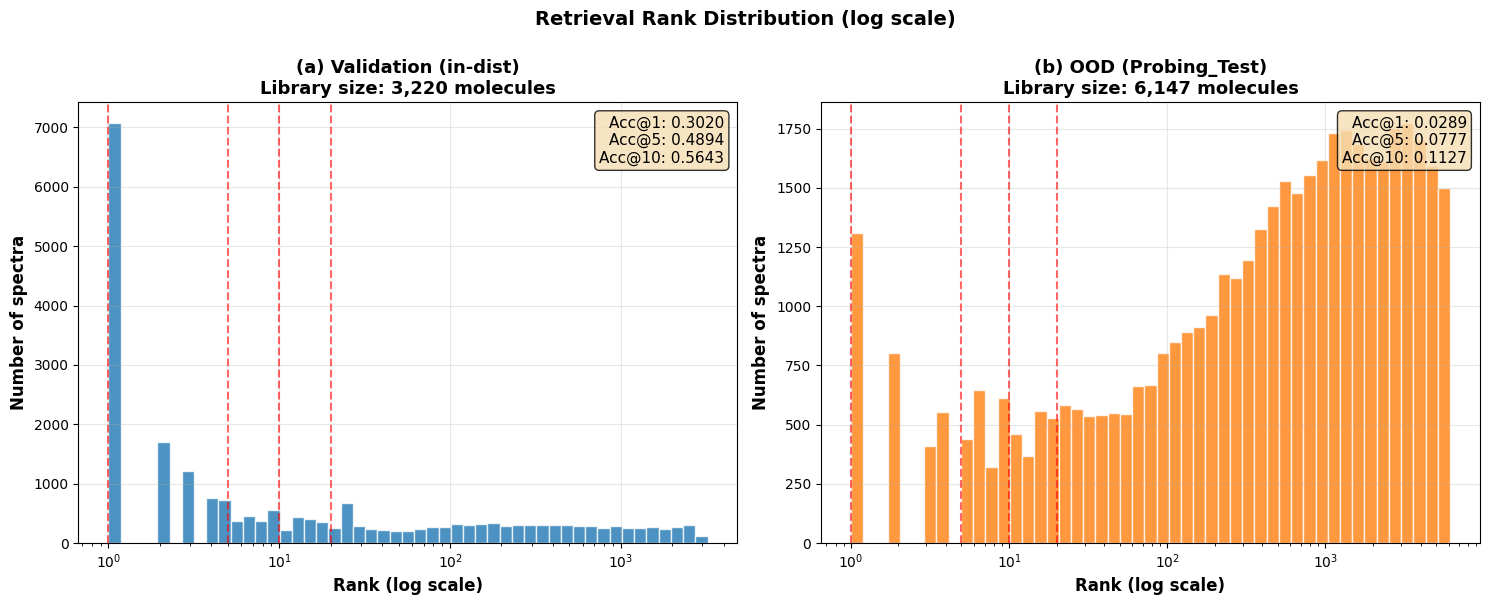

✓ Saved rank histogram to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/retrieval/rank_distribution.pdf


In [67]:
# ── Step 4: Rank distribution histograms ──

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation
ax = axes[0]
ax.hist(ranks_val, bins=np.logspace(0, np.log10(metrics_val['max_rank']), 50),
        color='tab:blue', alpha=0.8, edgecolor='white')
for k in [1, 5, 10, 20]:
    ax.axvline(k, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Rank (log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of spectra', fontsize=12, fontweight='bold')
ax.set_title(f'(a) Validation (in-dist)\nLibrary size: {metrics_val["library_size"]:,} molecules',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.97, f"Acc@1: {metrics_val['acc@1']:.4f}\nAcc@5: {metrics_val['acc@5']:.4f}\nAcc@10: {metrics_val['acc@10']:.4f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# OOD
ax = axes[1]
ax.hist(ranks_ood, bins=np.logspace(0, np.log10(metrics_ood['max_rank']), 50),
        color='tab:orange', alpha=0.8, edgecolor='white')
for k in [1, 5, 10, 20]:
    ax.axvline(k, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Rank (log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of spectra', fontsize=12, fontweight='bold')
ax.set_title(f'(b) OOD (Probing_Test)\nLibrary size: {metrics_ood["library_size"]:,} molecules',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.97, f"Acc@1: {metrics_ood['acc@1']:.4f}\nAcc@5: {metrics_ood['acc@5']:.4f}\nAcc@10: {metrics_ood['acc@10']:.4f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Retrieval Rank Distribution (log scale)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RETRIEVAL_DIR / 'rank_distribution.png', dpi=200, bbox_inches='tight')
plt.savefig(RETRIEVAL_DIR / 'rank_distribution.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved rank histogram to: {RETRIEVAL_DIR / 'rank_distribution.pdf'}")

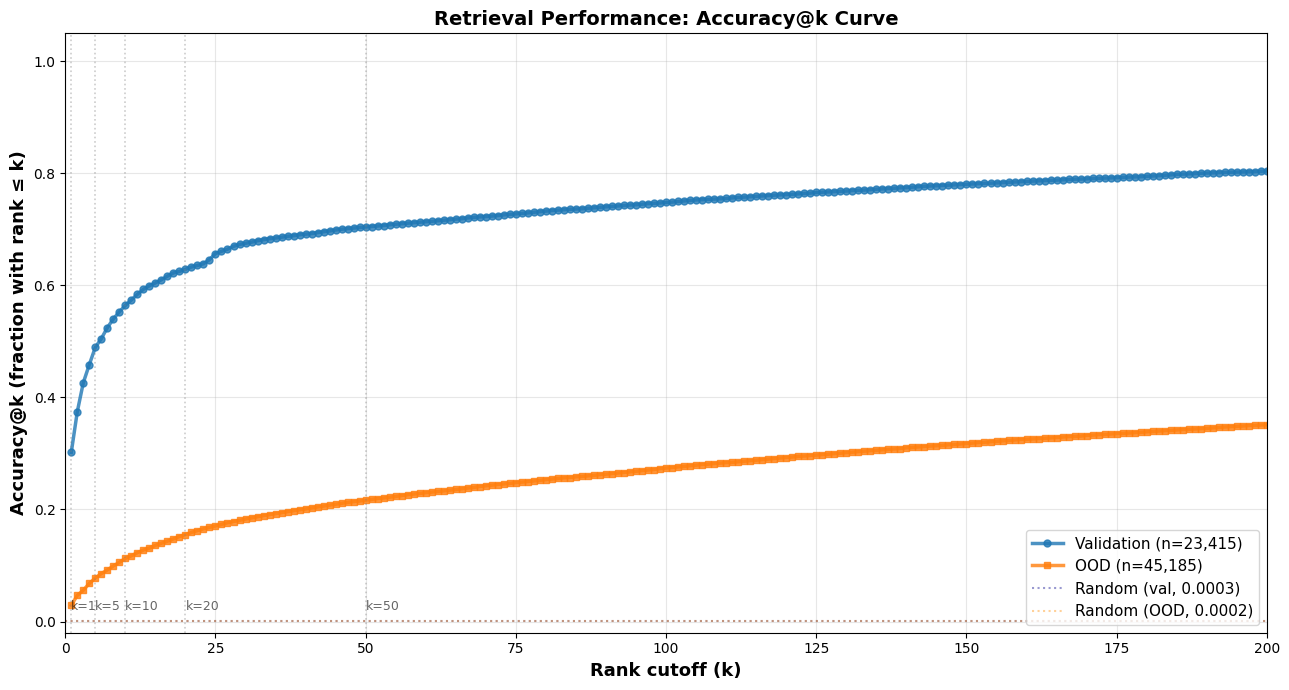

✓ Saved Accuracy@k curve to: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis/retrieval/accuracy_at_k_curve.pdf


In [69]:
# ── Step 5: Accuracy@k curves for increasing k ──

def compute_accuracy_at_k(ranks, max_k=None):
    """Compute accuracy@k for k from 1 to max_k."""
    if max_k is None:
        max_k = int(np.percentile(ranks, 99))
    
    ks = np.arange(1, max_k + 1)
    accs = np.array([(ranks <= k).mean() for k in ks])
    return ks, accs

max_k_val = int(min(200, int(np.percentile(ranks_val, 99.5))))
max_k_ood = int(min(200, int(np.percentile(ranks_ood, 99.5))))
max_k = max(max_k_val, max_k_ood)

ks_val, accs_val = compute_accuracy_at_k(ranks_val, max_k)
ks_ood, accs_ood = compute_accuracy_at_k(ranks_ood, max_k)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(ks_val, accs_val, 'o-', linewidth=2.5, markersize=5, 
        color='tab:blue', label=f'Validation (n={len(ranks_val):,})', alpha=0.8)
ax.plot(ks_ood, accs_ood, 's-', linewidth=2.5, markersize=5,
        color='tab:orange', label=f'OOD (n={len(ranks_ood):,})', alpha=0.8)

# Mark key values
for k in [1, 5, 10, 20, 50]:
    if k <= max_k:
        ax.axvline(k, color='grey', linestyle=':', linewidth=1.2, alpha=0.4)
        ax.text(k, 0.02, f'k={k}', rotation=0, fontsize=9, alpha=0.6)

# Add random baseline for reference
random_baseline_val = metrics_val['random_acc@1']
ax.axhline(random_baseline_val, color='darkblue', linestyle=':', linewidth=1.5, alpha=0.4,
           label=f'Random (val, {random_baseline_val:.4f})')

random_baseline_ood = metrics_ood['random_acc@1']
ax.axhline(random_baseline_ood, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.4,
           label=f'Random (OOD, {random_baseline_ood:.4f})')

ax.set_xlabel('Rank cutoff (k)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy@k (fraction with rank ≤ k)', fontsize=13, fontweight='bold')
ax.set_title('Retrieval Performance: Accuracy@k Curve', fontsize=14, fontweight='bold')

ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_k)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(RETRIEVAL_DIR / 'accuracy_at_k_curve.png', dpi=200, bbox_inches='tight')
plt.savefig(RETRIEVAL_DIR / 'accuracy_at_k_curve.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved Accuracy@k curve to: {RETRIEVAL_DIR / 'accuracy_at_k_curve.pdf'}")

In [70]:
# ── Step 6: Comprehensive retrieval metrics comparison table ──

retrieval_comparison = []

# Extract key metrics for comparison
metric_pairs = [
    ('Library Size', lambda m: f"{m['library_size']:,}"),
    ('Spectra (n)', lambda m: f"{m['n_spectra']:,}"),
    ('', lambda m: ''),  # Separator
    ('Accuracy@1', lambda m: f"{metrics_val['acc@1']:.4f}" if m is metrics_val else f"{metrics_ood['acc@1']:.4f}"),
    ('Accuracy@5', lambda m: f"{metrics_val['acc@5']:.4f}" if m is metrics_val else f"{metrics_ood['acc@5']:.4f}"),
    ('Accuracy@10', lambda m: f"{metrics_val['acc@10']:.4f}" if m is metrics_val else f"{metrics_ood['acc@10']:.4f}"),
    ('Accuracy@20', lambda m: f"{metrics_val['acc@20']:.4f}" if m is metrics_val else f"{metrics_ood['acc@20']:.4f}"),
    ('Accuracy@50', lambda m: f"{metrics_val['acc@50']:.4f}" if m is metrics_val else f"{metrics_ood['acc@50']:.4f}"),
    ('Accuracy@100', lambda m: f"{metrics_val['acc@100']:.4f}" if m is metrics_val else f"{metrics_ood['acc@100']:.4f}"),
    ('', lambda m: ''),  # Separator
    ('Mean Reciprocal Rank', lambda m: f"{metrics_val['mrr']:.4f}" if m is metrics_val else f"{metrics_ood['mrr']:.4f}"),
    ('Mean Rank', lambda m: f"{metrics_val['mean_rank']:.1f}" if m is metrics_val else f"{metrics_ood['mean_rank']:.1f}"),
    ('Median Rank', lambda m: f"{metrics_val['median_rank']:.0f}" if m is metrics_val else f"{metrics_ood['median_rank']:.0f}"),
    ('', lambda m: ''),  # Separator
    ('Random Baseline (Acc@1)', lambda m: f"{metrics_val['random_acc@1']:.2e}" if m is metrics_val else f"{metrics_ood['random_acc@1']:.2e}"),
    ('% Better than Random', lambda m: f"{metrics_val['pct_better_than_random']:.1f}%" if m is metrics_val else f"{metrics_ood['pct_better_than_random']:.1f}%"),
]

comparison_data = []
for metric_name, fn in metric_pairs:
    val_str = fn(metrics_val)
    ood_str = fn(metrics_ood)
    comparison_data.append({
        'Metric': metric_name,
        'Validation': val_str,
        'OOD (Probing Test)': ood_str,
        'Difference': '' if metric_name == '' else ('↓' if metric_name in ['Mean Rank', 'Median Rank'] and val_str != '' and ood_str != '' else '↑')
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*90)
print("RETRIEVAL EVALUATION: COMPREHENSIVE METRICS COMPARISON")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)

# Save to CSV
comparison_df.to_csv(RETRIEVAL_DIR / 'retrieval_comparison_table.csv', index=False)
print(f"✓ Saved comparison table to: {RETRIEVAL_DIR / 'retrieval_comparison_table.csv'}")

# Add key insights
print("\n" + "─"*90)
print("KEY INSIGHTS FROM RETRIEVAL EVALUATION:")
print("─"*90)

acc_drop_1 = (metrics_val['acc@1'] - metrics_ood['acc@1']) / metrics_val['acc@1'] * 100
acc_drop_5 = (metrics_val['acc@5'] - metrics_ood['acc@5']) / metrics_val['acc@5'] * 100
acc_drop_10 = (metrics_val['acc@10'] - metrics_ood['acc@10']) / metrics_val['acc@10'] * 100

mrr_drop = (metrics_val['mrr'] - metrics_ood['mrr']) / metrics_val['mrr'] * 100

print(f"• Accuracy@1 (exact match): {metrics_val['acc@1']:.4f} (val) → {metrics_ood['acc@1']:.4f} (OOD) = {acc_drop_1:.1f}% drop")
print(f"• Accuracy@5 (top-5 match): {metrics_val['acc@5']:.4f} (val) → {metrics_ood['acc@5']:.4f} (OOD) = {acc_drop_5:.1f}% drop")
print(f"• Accuracy@10 (top-10 match): {metrics_val['acc@10']:.4f} (val) → {metrics_ood['acc@10']:.4f} (OOD) = {acc_drop_10:.1f}% drop")
print(f"• Mean Reciprocal Rank: {metrics_val['mrr']:.4f} (val) → {metrics_ood['mrr']:.4f} (OOD) = {mrr_drop:.1f}% drop")
print(f"• Median rank: {metrics_val['median_rank']:.0f} (val) → {metrics_ood['median_rank']:.0f} (OOD)")
print(f"")
print(f"• {metrics_val['pct_better_than_random']:.1f}% of validation spectra beat random baseline")
print(f"• {metrics_ood['pct_better_than_random']:.1f}% of OOD spectra beat random baseline")
print(f"• Random baseline: 1 in {metrics_val['library_size']:,} (val) vs 1 in {metrics_ood['library_size']:,} (OOD)")
print("\n✓ Retrieval evaluation complete!")


RETRIEVAL EVALUATION: COMPREHENSIVE METRICS COMPARISON
                 Metric Validation OOD (Probing Test) Difference
           Library Size      3,220              6,147          ↑
            Spectra (n)     23,415             45,185          ↑
                                                                
             Accuracy@1     0.3020             0.0289          ↑
             Accuracy@5     0.4894             0.0777          ↑
            Accuracy@10     0.5643             0.1127          ↑
            Accuracy@20     0.6287             0.1551          ↑
            Accuracy@50     0.7043             0.2166          ↑
           Accuracy@100     0.7481             0.2739          ↑
                                                                
   Mean Reciprocal Rank     0.3882             0.0574          ↑
              Mean Rank      210.0             1213.5          ↓
            Median Rank          6                526          ↓
                                  

## 2. Output Distribution Analysis

Histogram of all raw prediction values, separated by ground truth class (active vs inactive bits).

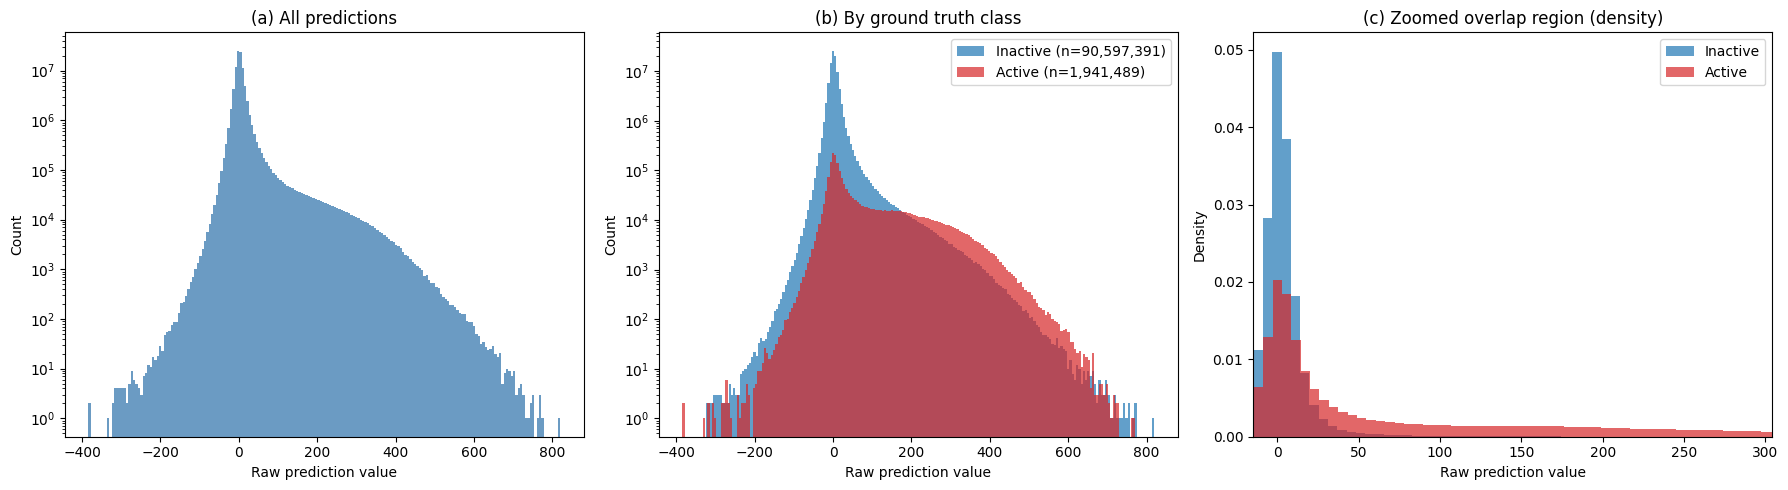


Prediction range: [-384.2497, 820.1191]
Mean (inactive): 3.6707 ± 19.6880
Mean (active):   72.0885 ± 106.3104
Bit sparsity (fraction active): 0.0210


In [71]:
# ── Distribution of raw model outputs ──
y_pred_flat = y_pred.ravel()
y_true_flat = y_true.ravel()

mask_active   = y_true_flat == 1
mask_inactive = y_true_flat == 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Overall distribution
axes[0].hist(y_pred_flat, bins=200, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Raw prediction value')
axes[0].set_ylabel('Count')
axes[0].set_title('(a) All predictions')
axes[0].set_yscale('log')

# (b) Split by ground truth class
axes[1].hist(y_pred_flat[mask_inactive], bins=200, alpha=0.7, color='tab:blue',
             label=f'Inactive (n={mask_inactive.sum():,})', edgecolor='none')
axes[1].hist(y_pred_flat[mask_active], bins=200, alpha=0.7, color='tab:red',
             label=f'Active (n={mask_active.sum():,})', edgecolor='none')
axes[1].set_xlabel('Raw prediction value')
axes[1].set_ylabel('Count')
axes[1].set_title('(b) By ground truth class')
axes[1].set_yscale('log')
axes[1].legend()

# (c) Zoomed-in overlap region
p5, p95 = np.percentile(y_pred_flat[mask_active], [5, 95])
axes[2].hist(y_pred_flat[mask_inactive], bins=200, alpha=0.7, color='tab:blue',
             label='Inactive', edgecolor='none', density=True)
axes[2].hist(y_pred_flat[mask_active], bins=200, alpha=0.7, color='tab:red',
             label='Active', edgecolor='none', density=True)
axes[2].set_xlim(p5 - 0.1, p95 + 0.1)
axes[2].set_xlabel('Raw prediction value')
axes[2].set_ylabel('Density')
axes[2].set_title('(c) Zoomed overlap region (density)')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_distribution.png', dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'output_distribution.pdf', bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\nPrediction range: [{y_pred_flat.min():.4f}, {y_pred_flat.max():.4f}]")
print(f"Mean (inactive): {y_pred_flat[mask_inactive].mean():.4f} ± {y_pred_flat[mask_inactive].std():.4f}")
print(f"Mean (active):   {y_pred_flat[mask_active].mean():.4f} ± {y_pred_flat[mask_active].std():.4f}")
print(f"Bit sparsity (fraction active): {mask_active.mean():.4f}")

## 3. Global Threshold Sweep

Sweep a threshold over raw predictions to binarize them. Compute precision, recall, F1, and Tanimoto (Jaccard) similarity at each threshold. Identify optimal operating points.

In [42]:
# ── Threshold sweep ──
from sklearn.metrics import precision_score, recall_score, f1_score

# Check cache first
sweep_cache_path = OUTPUT_DIR / 'threshold_sweep.csv'

if sweep_cache_path.exists():
    print("⚡ Loading cached threshold sweep results...")
    sweep_df = pd.read_csv(sweep_cache_path)
    print(f"✓ Cache loaded: {len(sweep_df)} thresholds")
else:
    print("Computing threshold sweep (this may take a while)...")
    thresholds = np.arange(0.01, 1.00, 0.01)
    results = []
    
    for t in tqdm(thresholds, desc="Threshold sweep"):
        y_bin = (y_pred >= t).astype(int)
        # Flatten for global metrics
        yb = y_bin.ravel()
        yt = y_true.ravel()
        
        # Tanimoto = |A ∩ B| / |A ∪ B|  (Jaccard index)
        intersection = np.logical_and(yb, yt).sum()
        union = np.logical_or(yb, yt).sum()
        tanimoto = intersection / union if union > 0 else 0.0
        
        prec = precision_score(yt, yb, zero_division=0)
        rec  = recall_score(yt, yb, zero_division=0)
        f1   = f1_score(yt, yb, zero_division=0)
        
        # Per-sample Tanimoto (averaged over molecules)
        inter_per_sample = np.logical_and(y_bin, y_true).sum(axis=1)
        union_per_sample = np.logical_or(y_bin, y_true).sum(axis=1)
        tanimoto_per_sample = np.where(union_per_sample > 0,
                                        inter_per_sample / union_per_sample, 0.0)
        
        results.append({
            'threshold': t,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'tanimoto_global': tanimoto,
            'tanimoto_mean': tanimoto_per_sample.mean(),
            'tanimoto_std': tanimoto_per_sample.std(),
            'n_pred_active': yb.sum(),
        })
    
    sweep_df = pd.DataFrame(results)
    sweep_df.to_csv(sweep_cache_path, index=False)

# Find optimal thresholds
best_f1_idx = sweep_df['f1'].idxmax()
best_tan_idx = sweep_df['tanimoto_mean'].idxmax()

print(f"Best F1:  threshold={sweep_df.loc[best_f1_idx, 'threshold']:.2f}, "
      f"F1={sweep_df.loc[best_f1_idx, 'f1']:.4f}, "
      f"P={sweep_df.loc[best_f1_idx, 'precision']:.4f}, "
      f"R={sweep_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"Best Tanimoto (mean per-sample): threshold={sweep_df.loc[best_tan_idx, 'threshold']:.2f}, "
      f"Tanimoto={sweep_df.loc[best_tan_idx, 'tanimoto_mean']:.4f} ± {sweep_df.loc[best_tan_idx, 'tanimoto_std']:.4f}")

OPTIMAL_THRESHOLD = sweep_df.loc[best_tan_idx, 'threshold']
print(f"\n→ Using optimal threshold (by mean Tanimoto): {OPTIMAL_THRESHOLD:.2f}")

⚡ Loading cached threshold sweep results...
✓ Cache loaded: 99 thresholds
Best F1:  threshold=0.99, F1=0.0580, P=0.0302, R=0.7578
Best Tanimoto (mean per-sample): threshold=0.99, Tanimoto=0.0295 ± 0.0119

→ Using optimal threshold (by mean Tanimoto): 0.99


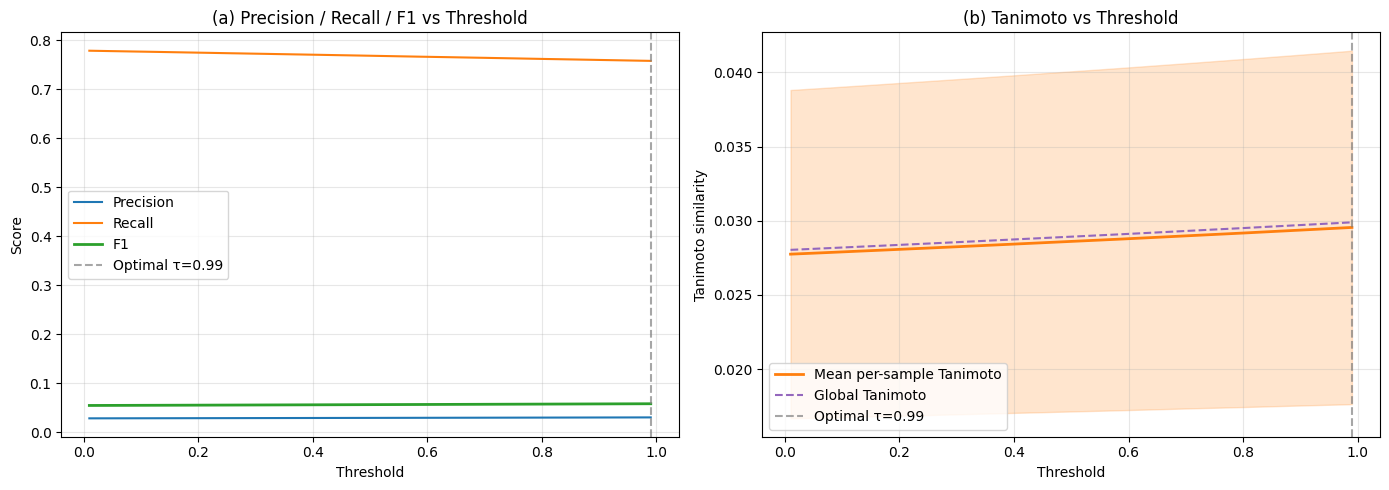

In [43]:
# ── Plot threshold sweep ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Precision / Recall / F1
axes[0].plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', linewidth=1.5)
axes[0].plot(sweep_df['threshold'], sweep_df['recall'], label='Recall', linewidth=1.5)
axes[0].plot(sweep_df['threshold'], sweep_df['f1'], label='F1', linewidth=2, color='tab:green')
axes[0].axvline(OPTIMAL_THRESHOLD, color='grey', linestyle='--', alpha=0.7,
                label=f'Optimal τ={OPTIMAL_THRESHOLD:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('(a) Precision / Recall / F1 vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Tanimoto (per-sample mean)
axes[1].plot(sweep_df['threshold'], sweep_df['tanimoto_mean'],
             label='Mean per-sample Tanimoto', linewidth=2, color='tab:orange')
axes[1].fill_between(sweep_df['threshold'],
                      sweep_df['tanimoto_mean'] - sweep_df['tanimoto_std'],
                      sweep_df['tanimoto_mean'] + sweep_df['tanimoto_std'],
                      alpha=0.2, color='tab:orange')
axes[1].plot(sweep_df['threshold'], sweep_df['tanimoto_global'],
             label='Global Tanimoto', linewidth=1.5, color='tab:purple', linestyle='--')
axes[1].axvline(OPTIMAL_THRESHOLD, color='grey', linestyle='--', alpha=0.7,
                label=f'Optimal τ={OPTIMAL_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Tanimoto similarity')
axes[1].set_title('(b) Tanimoto vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_sweep.png', dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'threshold_sweep.pdf', bbox_inches='tight')
plt.show()

## 4. Per-Bit AUROC

Compute AUROC for each of the 2048 Morgan fingerprint bits individually. Bits that are always 0 or always 1 in the ground truth are flagged as non-informative.

In [44]:
# ── Per-bit AUROC ──
from sklearn.metrics import roc_auc_score

# Check cache first
bit_stats_path = OUTPUT_DIR / 'per_bit_stats.csv'

if bit_stats_path.exists():
    print("⚡ Loading cached per-bit statistics...")
    bit_df = pd.read_csv(bit_stats_path)
    print(f"✓ Cache loaded: {len(bit_df)} bits")
else:
    print("Computing per-bit AUROC...")
    n_bits = y_true.shape[1]
    bit_stats = []
    
    for bit_idx in tqdm(range(n_bits), desc="Per-bit AUROC"):
        yt = y_true[:, bit_idx]
        yp = y_pred[:, bit_idx]
        
        freq = yt.mean()  # fraction of molecules with this bit active
        n_active = int(yt.sum())
        
        # AUROC requires both classes present
        if n_active == 0 or n_active == len(yt):
            auroc = np.nan
        else:
            auroc = roc_auc_score(yt, yp)
        
        # Per-bit accuracy at optimal threshold
        yb = (yp >= OPTIMAL_THRESHOLD).astype(int)
        acc = (yb == yt).mean()
        tp = np.logical_and(yb == 1, yt == 1).sum()
        fp = np.logical_and(yb == 1, yt == 0).sum()
        fn = np.logical_and(yb == 0, yt == 1).sum()
        tn = np.logical_and(yb == 0, yt == 0).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        bit_stats.append({
            'bit_idx': bit_idx,
            'frequency': freq,
            'n_active': n_active,
            'auroc': auroc,
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        })
    
    bit_df = pd.DataFrame(bit_stats)
    bit_df.to_csv(bit_stats_path, index=False)

valid_bits = bit_df.dropna(subset=['auroc'])
n_bits = len(bit_df)
print(f"Total bits: {n_bits}")
print(f"Valid bits (both classes present): {len(valid_bits)}")
print(f"Zero-variance bits (always 0): {(bit_df['n_active'] == 0).sum()}")
print(f"Always-active bits (always 1): {(bit_df['n_active'] == len(y_true)).sum()}")
print(f"\nAUROC summary (valid bits):")
print(f"  Mean:   {valid_bits['auroc'].mean():.4f}")
print(f"  Median: {valid_bits['auroc'].median():.4f}")
print(f"  Std:    {valid_bits['auroc'].std():.4f}")
print(f"  Min:    {valid_bits['auroc'].min():.4f}")
print(f"  Max:    {valid_bits['auroc'].max():.4f}")
print(f"  >0.9:   {(valid_bits['auroc'] > 0.9).sum()} bits")
print(f"  >0.8:   {(valid_bits['auroc'] > 0.8).sum()} bits")
print(f"  <0.6:   {(valid_bits['auroc'] < 0.6).sum()} bits")

⚡ Loading cached per-bit statistics...
✓ Cache loaded: 2048 bits
Total bits: 2048
Valid bits (both classes present): 2048
Zero-variance bits (always 0): 0
Always-active bits (always 1): 0

AUROC summary (valid bits):
  Mean:   0.5910
  Median: 0.5869
  Std:    0.0961
  Min:    0.2721
  Max:    0.9146
  >0.9:   1 bits
  >0.8:   46 bits
  <0.6:   1144 bits


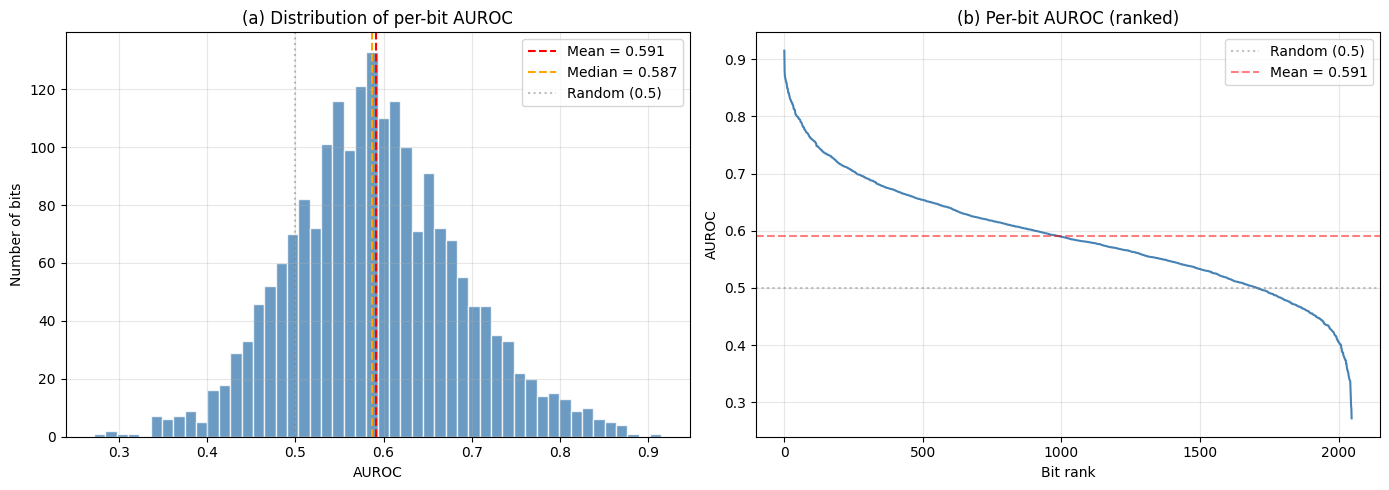

In [45]:
# ── AUROC distribution histogram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) AUROC histogram
axes[0].hist(valid_bits['auroc'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(valid_bits['auroc'].mean(), color='red', linestyle='--',
                label=f"Mean = {valid_bits['auroc'].mean():.3f}")
axes[0].axvline(valid_bits['auroc'].median(), color='orange', linestyle='--',
                label=f"Median = {valid_bits['auroc'].median():.3f}")
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Random (0.5)')
axes[0].set_xlabel('AUROC')
axes[0].set_ylabel('Number of bits')
axes[0].set_title('(a) Distribution of per-bit AUROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Sorted AUROC (rank plot)
sorted_auroc = valid_bits['auroc'].sort_values(ascending=False).values
axes[1].plot(range(len(sorted_auroc)), sorted_auroc, linewidth=1.5, color='steelblue')
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5, label='Random (0.5)')
axes[1].axhline(valid_bits['auroc'].mean(), color='red', linestyle='--', alpha=0.5,
                label=f"Mean = {valid_bits['auroc'].mean():.3f}")
axes[1].set_xlabel('Bit rank')
axes[1].set_ylabel('AUROC')
axes[1].set_title('(b) Per-bit AUROC (ranked)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_bit_auroc_distribution.png', dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'per_bit_auroc_distribution.pdf', bbox_inches='tight')
plt.show()

## 5. AUROC vs Bit Frequency

Scatter plot of per-bit AUROC against bit frequency (fraction of molecules with that bit active). This reveals whether rare or common substructures are easier to predict.

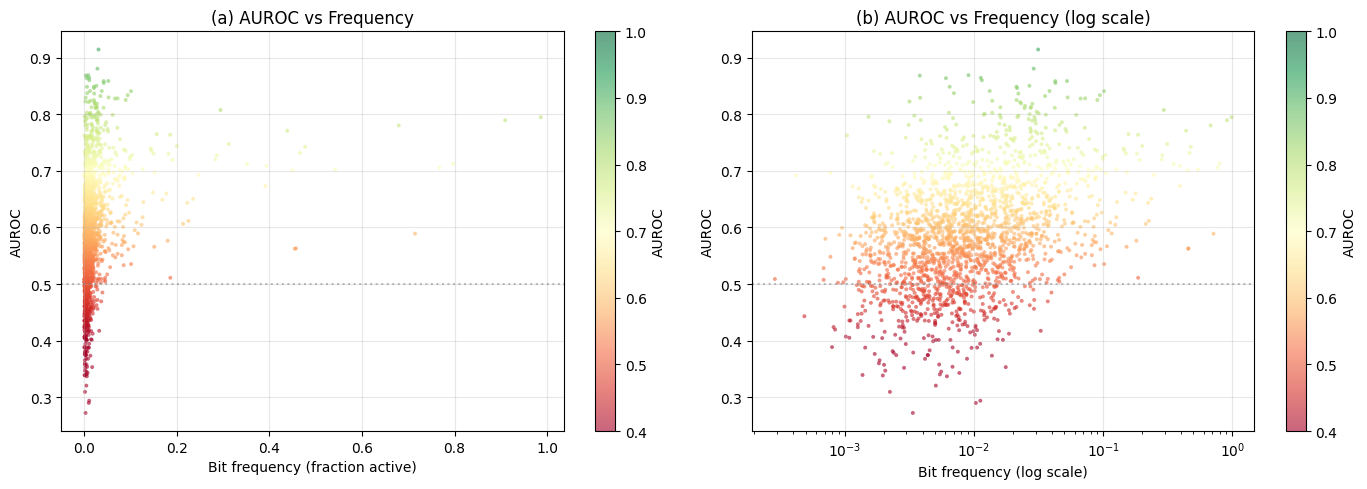

Spearman correlation (frequency vs AUROC): ρ = 0.3798, p = 2.84e-71

AUROC by frequency bin:
    freq_bin  n_bits  mean_auroc  median_auroc  std_auroc
 (0.0, 0.01]    1167    0.564124      0.565716   0.088494
(0.01, 0.05]     742    0.617975      0.614632   0.094438
 (0.05, 0.1]      87    0.666566      0.677580   0.079999
  (0.1, 0.2]      26    0.662965      0.661029   0.082035
  (0.2, 0.5]      19    0.690543      0.709044   0.068318
  (0.5, 1.0]       7    0.725021      0.713005   0.072599


In [46]:
# ── AUROC vs Frequency scatter ──
from scipy.stats import spearmanr

vb = valid_bits.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Linear frequency scale
sc = axes[0].scatter(vb['frequency'], vb['auroc'], c=vb['auroc'], cmap='RdYlGn',
                     s=8, alpha=0.6, edgecolors='none', vmin=0.4, vmax=1.0)
axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Bit frequency (fraction active)')
axes[0].set_ylabel('AUROC')
axes[0].set_title('(a) AUROC vs Frequency')
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[0], label='AUROC')

# (b) Log frequency scale
sc2 = axes[1].scatter(vb['frequency'], vb['auroc'], c=vb['auroc'], cmap='RdYlGn',
                      s=8, alpha=0.6, edgecolors='none', vmin=0.4, vmax=1.0)
axes[1].set_xscale('log')
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Bit frequency (log scale)')
axes[1].set_ylabel('AUROC')
axes[1].set_title('(b) AUROC vs Frequency (log scale)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='AUROC')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auroc_vs_frequency.png', dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'auroc_vs_frequency.pdf', bbox_inches='tight')
plt.show()

# Correlation
rho, pval = spearmanr(vb['frequency'], vb['auroc'])
print(f"Spearman correlation (frequency vs AUROC): ρ = {rho:.4f}, p = {pval:.2e}")

# Frequency bin analysis
freq_bins = [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
vb['freq_bin'] = pd.cut(vb['frequency'], bins=freq_bins)
freq_summary = vb.groupby('freq_bin', observed=True).agg(
    n_bits=('auroc', 'count'),
    mean_auroc=('auroc', 'mean'),
    median_auroc=('auroc', 'median'),
    std_auroc=('auroc', 'std'),
).reset_index()
print("\nAUROC by frequency bin:")
print(freq_summary.to_string(index=False))

## 6. Chemical Interpretation of Best/Worst Bits

Use RDKit to identify the substructure patterns associated with the top-20 and bottom-20 AUROC bits. Morgan fingerprint bits correspond to specific atom environments (ECFP-like features).

In [47]:
# ── Chemical interpretation: identify substructures for top/bottom bits ──
from rdkit.Chem import AllChem, Draw
from collections import Counter

def get_bit_environments(smiles_list, bit_indices, radius=2, fp_size=2048, n_mols=500):
    """For each bit index, find example molecules and the atom environments that set that bit."""
    np.random.seed(SEED)
    # Sample molecules for efficiency
    sample_idx = np.random.choice(len(smiles_list), min(n_mols, len(smiles_list)), replace=False)
    
    bit_info_dict = {b: [] for b in bit_indices}
    bit_smarts_counter = {b: Counter() for b in bit_indices}
    
    for idx in sample_idx:
        smi = smiles_list[idx]
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        
        bi = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_size, bitInfo=bi)
        
        for bit_idx in bit_indices:
            if bit_idx in bi:
                bit_info_dict[bit_idx].append((smi, mol, bi[bit_idx]))
                # Get SMARTS for the environment
                for atom_idx, rad in bi[bit_idx]:
                    if rad > 0:
                        env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                        amap = {}
                        submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                        smarts = Chem.MolToSmarts(submol)
                        bit_smarts_counter[bit_idx][smarts] += 1
                    else:
                        # Radius 0: just the atom
                        atom = mol.GetAtomWithIdx(atom_idx)
                        smarts = f"[{atom.GetSymbol()}]"
                        bit_smarts_counter[bit_idx][smarts] += 1
    
    return bit_info_dict, bit_smarts_counter

# Get top 20 and bottom 20 bits by AUROC
top20 = valid_bits.nlargest(20, 'auroc')
bottom20 = valid_bits.nsmallest(20, 'auroc')

all_bits_of_interest = list(top20['bit_idx'].values) + list(bottom20['bit_idx'].values)
smiles_list_for_interp = df_test['smiles'].tolist()

print("Analyzing substructure environments for top/bottom AUROC bits...")
bit_info, bit_smarts = get_bit_environments(smiles_list_for_interp, all_bits_of_interest)

# Build interpretation table
interp_rows = []
for _, row in pd.concat([top20, bottom20]).iterrows():
    bit_idx = int(row['bit_idx'])
    top_smarts = bit_smarts[bit_idx].most_common(3)
    smarts_str = ' | '.join([f"{s} (n={c})" for s, c in top_smarts]) if top_smarts else 'N/A'
    n_examples = len(bit_info[bit_idx])
    interp_rows.append({
        'bit_idx': bit_idx,
        'auroc': row['auroc'],
        'frequency': row['frequency'],
        'n_active': row['n_active'],
        'top_smarts': smarts_str,
        'n_example_mols': n_examples,
        'rank_group': 'top20' if row['auroc'] >= top20['auroc'].min() else 'bottom20',
    })

interp_df = pd.DataFrame(interp_rows)
interp_df.to_csv(OUTPUT_DIR / 'bit_interpretation.csv', index=False)

print("\n=== TOP 20 BITS (highest AUROC) ===")
for _, r in interp_df[interp_df['rank_group'] == 'top20'].iterrows():
    print(f"  Bit {r['bit_idx']:4d} | AUROC={r['auroc']:.4f} | freq={r['frequency']:.4f} | {r['top_smarts'][:80]}")

print("\n=== BOTTOM 20 BITS (lowest AUROC) ===")
for _, r in interp_df[interp_df['rank_group'] == 'bottom20'].iterrows():
    print(f"  Bit {r['bit_idx']:4d} | AUROC={r['auroc']:.4f} | freq={r['frequency']:.4f} | {r['top_smarts'][:80]}")

Analyzing substructure environments for top/bottom AUROC bits...

=== TOP 20 BITS (highest AUROC) ===
  Bit 1037 | AUROC=0.9146 | freq=0.0314 | [#6]-[#6](-[#6](-[#6](-[#6])-[#8])-[#8])-[#8] (n=8) | [#8]-[#6@@H](-[#6@@H](-[#6
  Bit 1234 | AUROC=0.8808 | freq=0.0290 | [#6]-[#6](-[#6](-[#8]-[#6])-[#6]-[#8])-[#8] (n=8) | [#8](-[#6@@H](-[#6@H](-[#6@H
  Bit 1209 | AUROC=0.8693 | freq=0.0091 | [#6]:[#6](:[#6]:[#6](:[#6])-[#17])-[#17] (n=5) | [#6]:[#7]:[#7H]:[#6](=[#8]):[#7
  Bit 1100 | AUROC=0.8685 | freq=0.0038 | [#6]-[#6](:[#6](:[#6]:[#6])-[#17]):[#6] (n=4)
  Bit 1466 | AUROC=0.8647 | freq=0.0113 | [#6]-[#6](:[#6]):[#8]:[#6]:[#6] (n=2) | [#6]-[#7](-[#6])-[#6](-[#6]-[#6])=[#8] (
  Bit  241 | AUROC=0.8639 | freq=0.0061 | N/A
  Bit  594 | AUROC=0.8602 | freq=0.0115 | [#6]:[#6](:[#6](:[#6](:[#6])-[#8])-[#6])-[#8] (n=2) | [#6]:[#6](:[#6](:[#6](-[#8
  Bit 1323 | AUROC=0.8589 | freq=0.0525 | [#8]-[#6@@H](-[#6@@H])-[#8] (n=14) | [#8]-[#6](-[#6])-[#8] (n=14) | [#7](-[#6@@H
  Bit  816 | AUROC=0.8588 

Top 5 best-predicted bits (example molecules with highlighted environments):

Best AUROC - Bit 1037


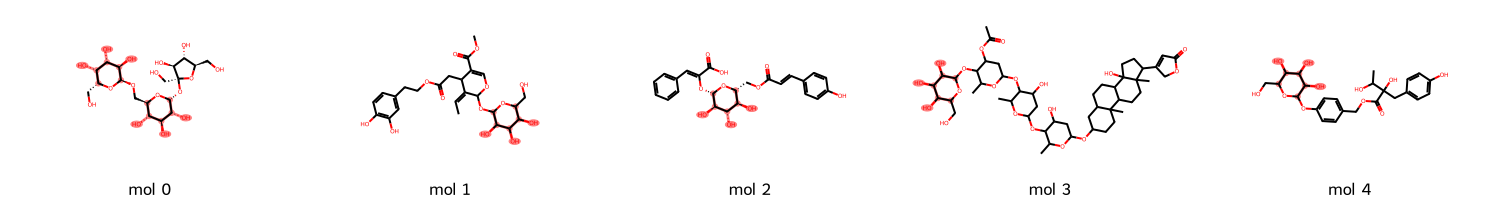


Best AUROC - Bit 1234


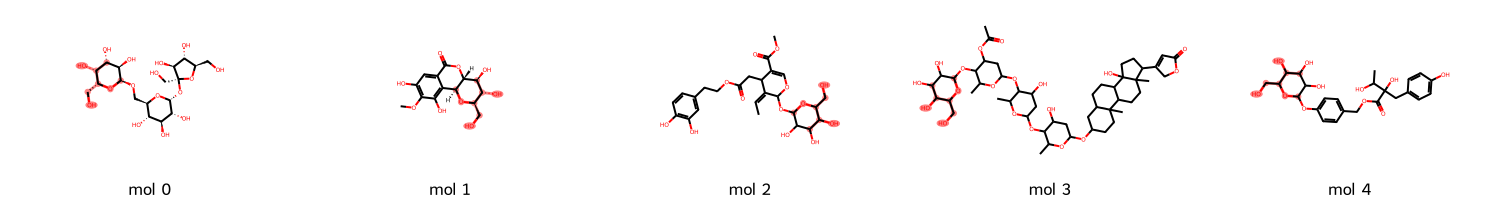


Best AUROC - Bit 1209


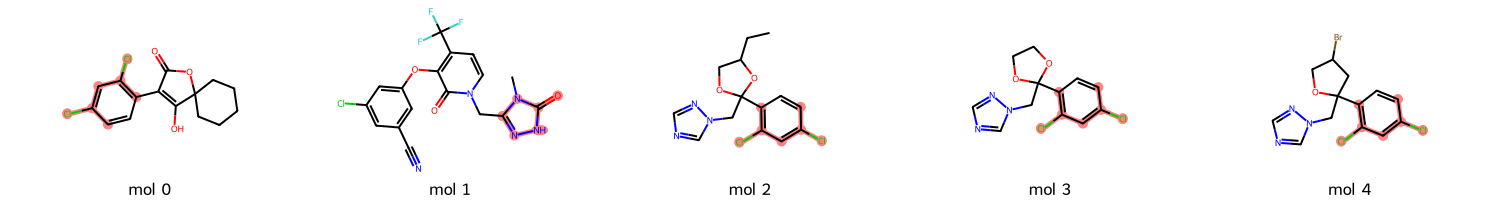


Best AUROC - Bit 1100


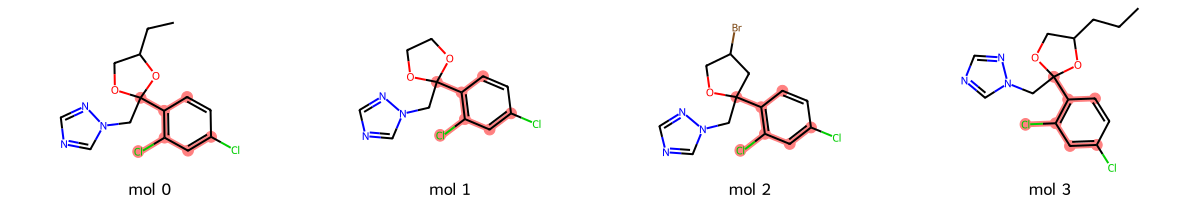


Best AUROC - Bit 1466


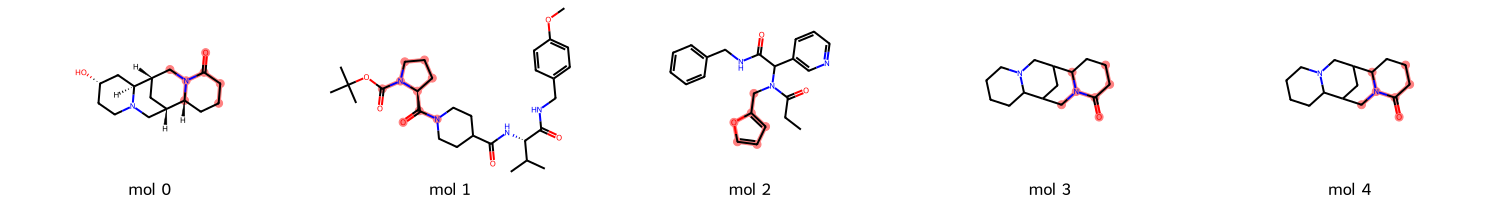


Top 5 worst-predicted bits (example molecules with highlighted environments):

Worst AUROC - Bit 1305


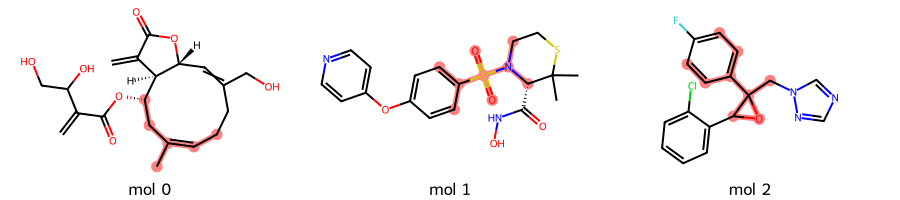


Worst AUROC - Bit 365


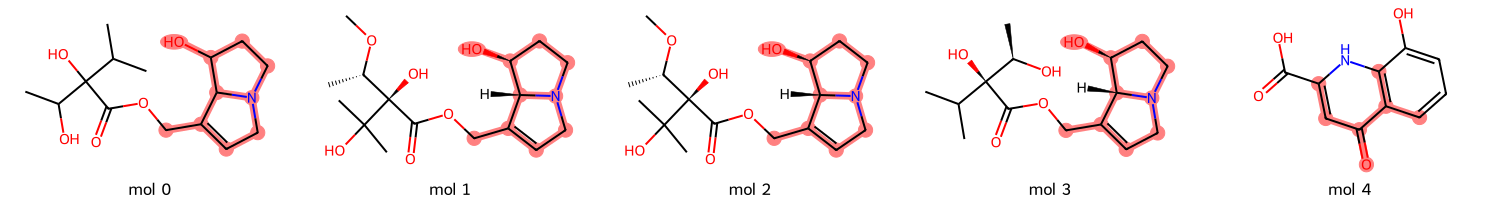


Worst AUROC - Bit 178


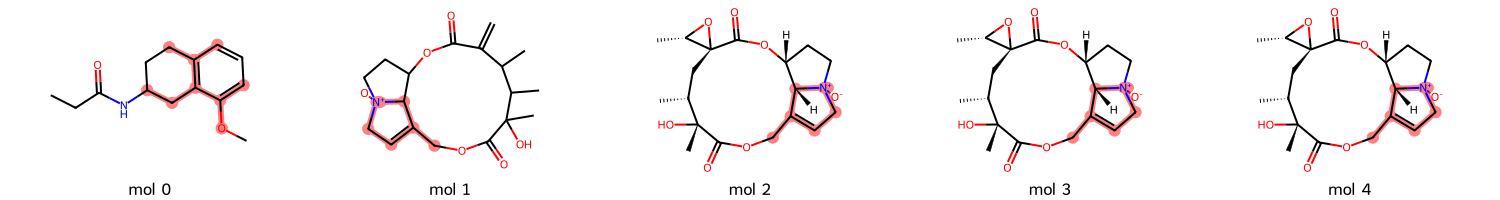


Worst AUROC - Bit 1161


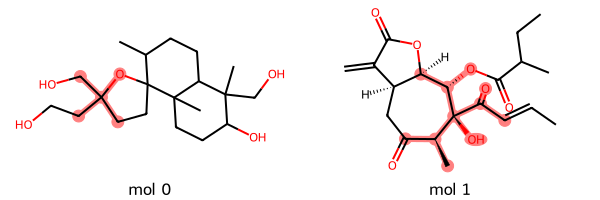


Worst AUROC - Bit 1253


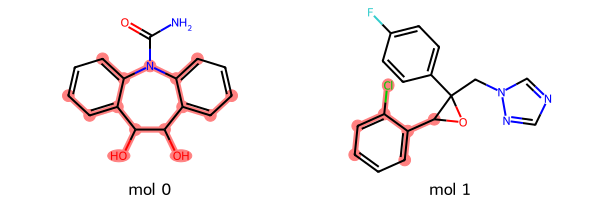

In [48]:
# ── Visualize example molecules for top/bottom bits ──
def draw_bit_examples(bit_info_dict, bit_indices, title_prefix, n_show=5):
    """Draw example molecules highlighting the atom environments for given bits."""
    for bit_idx in bit_indices[:5]:  # Show top 5 bits
        examples = bit_info_dict.get(bit_idx, [])
        if not examples:
            continue
        
        mols = []
        highlights = []
        for smi, mol, atominfo in examples[:n_show]:
            atoms_to_highlight = set()
            for atom_idx, rad in atominfo:
                if rad > 0:
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                    amap = {}
                    Chem.PathToSubmol(mol, env, atomMap=amap)
                    atoms_to_highlight.update(amap.keys())
                else:
                    atoms_to_highlight.add(atom_idx)
            mols.append(mol)
            highlights.append(list(atoms_to_highlight))
        
        if mols:
            img = Draw.MolsToGridImage(mols, molsPerRow=min(5, len(mols)),
                                        subImgSize=(300, 200),
                                        highlightAtomLists=highlights,
                                        legends=[f"mol {i}" for i in range(len(mols))])
            print(f"\n{title_prefix} - Bit {bit_idx}")
            display(img)

print("Top 5 best-predicted bits (example molecules with highlighted environments):")
draw_bit_examples(bit_info, list(top20['bit_idx'].values), "Best AUROC")

print("\nTop 5 worst-predicted bits (example molecules with highlighted environments):")
draw_bit_examples(bit_info, list(bottom20['bit_idx'].values), "Worst AUROC")

## 7. Bit-Level Performance by Chemical Category

Classify Morgan fingerprint bits into chemical categories based on their substructure environments, then compare average AUROC across categories.

In [49]:
# ── Classify bits into chemical categories ──
def classify_bits_by_chemistry(smiles_list, n_bits=2048, radius=2, n_mols=1000):
    """
    Classify each Morgan FP bit into a chemical category based on
    the most common atom environment that triggers it.
    
    Categories:
    - aromatic: contains aromatic atoms/bonds
    - heteroatom: contains N, O, S, P, F, Cl, Br, I (non-carbon heavy atoms)
    - aliphatic_ring: non-aromatic ring system
    - aliphatic_chain: open-chain carbon-only environment
    - mixed: contains both aromatic and heteroatom features
    - unclassified: could not determine
    """
    np.random.seed(SEED)
    sample_idx = np.random.choice(len(smiles_list), min(n_mols, len(smiles_list)), replace=False)
    
    bit_categories = {}
    bit_atom_info = {b: Counter() for b in range(n_bits)}
    
    heteroatoms = {'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'Se', 'Si', 'B'}
    
    for idx in sample_idx:
        mol = Chem.MolFromSmiles(smiles_list[idx])
        if mol is None:
            continue
        
        bi = {}
        AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits, bitInfo=bi)
        
        for bit_idx, atom_envs in bi.items():
            for atom_idx, rad in atom_envs:
                atom = mol.GetAtomWithIdx(atom_idx)
                is_aromatic = atom.GetIsAromatic()
                symbol = atom.GetSymbol()
                is_hetero = symbol in heteroatoms
                is_in_ring = atom.IsInRing()
                
                # Also check neighbors within radius
                if rad > 0:
                    env_bonds = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                    amap = {}
                    Chem.PathToSubmol(mol, env_bonds, atomMap=amap)
                    env_atoms = [mol.GetAtomWithIdx(a) for a in amap.keys()]
                    any_aromatic = any(a.GetIsAromatic() for a in env_atoms)
                    any_hetero = any(a.GetSymbol() in heteroatoms for a in env_atoms)
                    any_ring = any(a.IsInRing() for a in env_atoms)
                else:
                    any_aromatic = is_aromatic
                    any_hetero = is_hetero
                    any_ring = is_in_ring
                
                # Classify this particular observation
                if any_aromatic and any_hetero:
                    cat = 'aromatic+heteroatom'
                elif any_aromatic:
                    cat = 'aromatic'
                elif any_hetero and any_ring:
                    cat = 'heteroatom+ring'
                elif any_hetero:
                    cat = 'heteroatom'
                elif any_ring:
                    cat = 'aliphatic_ring'
                else:
                    cat = 'aliphatic_chain'
                
                bit_atom_info[bit_idx][cat] += 1
    
    # Assign majority category to each bit
    for bit_idx in range(n_bits):
        if bit_atom_info[bit_idx]:
            bit_categories[bit_idx] = bit_atom_info[bit_idx].most_common(1)[0][0]
        else:
            bit_categories[bit_idx] = 'unclassified'
    
    return bit_categories

print("Classifying bits by chemical category (sampling 1000 molecules)...")
bit_cats = classify_bits_by_chemistry(smiles_list, n_bits=2048)

# Add to bit_df
bit_df['category'] = bit_df['bit_idx'].map(bit_cats)

cat_counts = bit_df['category'].value_counts()
print("\nBit counts per category:")
for cat, count in cat_counts.items():
    print(f"  {cat:25s}: {count:5d}")

# Category-wise AUROC
cat_auroc = bit_df.dropna(subset=['auroc']).groupby('category').agg(
    n_bits=('auroc', 'count'),
    mean_auroc=('auroc', 'mean'),
    median_auroc=('auroc', 'median'),
    std_auroc=('auroc', 'std'),
    mean_frequency=('frequency', 'mean'),
).sort_values('mean_auroc', ascending=False).reset_index()

print("\nAUROC by chemical category:")
print(cat_auroc.to_string(index=False))

Classifying bits by chemical category (sampling 1000 molecules)...

Bit counts per category:
  aromatic+heteroatom      :   949
  heteroatom+ring          :   508
  heteroatom               :   195
  aromatic                 :   140
  aliphatic_ring           :   133
  unclassified             :    66
  aliphatic_chain          :    57

AUROC by chemical category:
           category  n_bits  mean_auroc  median_auroc  std_auroc  mean_frequency
         heteroatom     195    0.615036      0.607438   0.089236        0.032393
     aliphatic_ring     133    0.609771      0.604173   0.097744        0.029647
    aliphatic_chain      57    0.608853      0.615717   0.065737        0.056833
           aromatic     140    0.600347      0.601602   0.083817        0.051876
    heteroatom+ring     508    0.592680      0.587149   0.106631        0.016756
aromatic+heteroatom     949    0.583380      0.579255   0.092801        0.014287
       unclassified      66    0.542440      0.546225   0.091730  

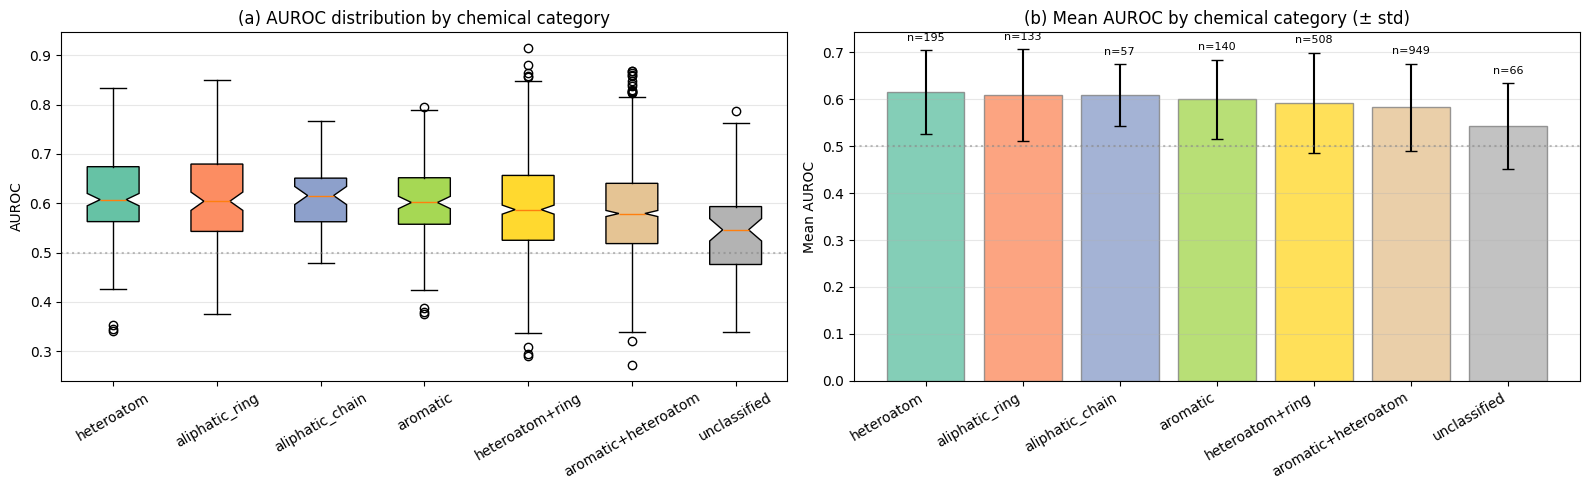

In [50]:
# ── Plot category-wise AUROC ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Box plot of AUROC by category
cat_order = cat_auroc['category'].tolist()
data_per_cat = [bit_df.dropna(subset=['auroc']).loc[
    bit_df['category'] == cat, 'auroc'].values for cat in cat_order]

bp = axes[0].boxplot(data_per_cat, labels=cat_order, patch_artist=True, notch=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(cat_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('AUROC')
axes[0].set_title('(a) AUROC distribution by chemical category')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='y')

# (b) Bar plot of mean AUROC per category with error bars
x_pos = range(len(cat_auroc))
axes[1].bar(x_pos, cat_auroc['mean_auroc'], yerr=cat_auroc['std_auroc'],
            capsize=4, color=colors[:len(cat_order)], edgecolor='grey', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(cat_auroc['category'], rotation=30, ha='right')
axes[1].set_ylabel('Mean AUROC')
axes[1].set_title('(b) Mean AUROC by chemical category (± std)')
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

# Add count annotations
for i, (_, row) in enumerate(cat_auroc.iterrows()):
    axes[1].text(i, row['mean_auroc'] + row['std_auroc'] + 0.02,
                 f"n={row['n_bits']}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auroc_by_category.png', dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'auroc_by_category.pdf', bbox_inches='tight')
plt.show()

## 8. Summary Statistics Table

Comprehensive summary of all metrics, both global (cosine similarity, Tanimoto) and per-bit (AUROC distribution, accuracy, F1).

In [51]:
# ── Comprehensive summary table ──

# Global metrics (using optimal threshold)
y_bin_opt = (y_pred >= OPTIMAL_THRESHOLD).astype(int)
yt_flat = y_true.ravel()
yb_flat = y_bin_opt.ravel()

# Per-sample Tanimoto at optimal threshold
inter_ps = np.logical_and(y_bin_opt, y_true).sum(axis=1)
union_ps = np.logical_or(y_bin_opt, y_true).sum(axis=1)
tanimoto_ps = np.where(union_ps > 0, inter_ps / union_ps, 0.0)

# Cosine similarity (already computed during inference, reload if needed)
cos_sim_file = OUTPUT_DIR / 'cosine_similarities.npy'
if cos_sim_file.exists():
    cos_sims = np.load(cos_sim_file)
else:
    from numpy.linalg import norm
    cos_sims = np.array([
        np.dot(y_pred[i], y_true[i]) / (norm(y_pred[i]) * norm(y_true[i]) + 1e-8)
        for i in range(len(y_true))
    ])

vb = bit_df.dropna(subset=['auroc'])

summary = {
    'Metric': [
        '--- Global Metrics ---',
        'N spectra (probing_test)',
        'N fingerprint bits',
        'Valid bits (both classes present)',
        'Cosine similarity (mean ± std)',
        'Cosine similarity (median)',
        f'Tanimoto @ τ={OPTIMAL_THRESHOLD:.2f} (mean ± std)',
        f'Tanimoto @ τ={OPTIMAL_THRESHOLD:.2f} (median)',
        f'Global F1 @ τ={OPTIMAL_THRESHOLD:.2f}',
        f'Global Precision @ τ={OPTIMAL_THRESHOLD:.2f}',
        f'Global Recall @ τ={OPTIMAL_THRESHOLD:.2f}',
        'Optimal threshold (by Tanimoto)',
        '--- Per-Bit AUROC ---',
        'Mean AUROC',
        'Median AUROC',
        'Std AUROC',
        'Min AUROC',
        'Max AUROC', 
        'Bits with AUROC > 0.9',
        'Bits with AUROC > 0.8',
        'Bits with AUROC > 0.7',
        'Bits with AUROC < 0.6',
        '--- Per-Bit (at optimal τ) ---',
        'Mean accuracy',
        'Mean F1',
        'Mean precision',
        'Mean recall',
        '--- Bit Activity ---',
        'Mean bit frequency',
        'Median bit frequency',
        'Always-inactive bits',
        'Spearman ρ (freq vs AUROC)',
    ],
    'Value': [
        '',
        f'{len(y_true):,}',
        f'{n_bits}',
        f'{len(vb)}',
        f'{cos_sims.mean():.4f} ± {cos_sims.std():.4f}',
        f'{np.median(cos_sims):.4f}',
        f'{tanimoto_ps.mean():.4f} ± {tanimoto_ps.std():.4f}',
        f'{np.median(tanimoto_ps):.4f}',
        f'{f1_score(yt_flat, yb_flat, zero_division=0):.4f}',
        f'{precision_score(yt_flat, yb_flat, zero_division=0):.4f}',
        f'{recall_score(yt_flat, yb_flat, zero_division=0):.4f}',
        f'{OPTIMAL_THRESHOLD:.2f}',
        '',
        f'{vb["auroc"].mean():.4f}',
        f'{vb["auroc"].median():.4f}',
        f'{vb["auroc"].std():.4f}',
        f'{vb["auroc"].min():.4f}',
        f'{vb["auroc"].max():.4f}',
        f'{(vb["auroc"] > 0.9).sum()}',
        f'{(vb["auroc"] > 0.8).sum()}',
        f'{(vb["auroc"] > 0.7).sum()}',
        f'{(vb["auroc"] < 0.6).sum()}',
        '',
        f'{vb["accuracy"].mean():.4f}',
        f'{vb["f1"].mean():.4f}',
        f'{vb["precision"].mean():.4f}',
        f'{vb["recall"].mean():.4f}',
        '',
        f'{vb["frequency"].mean():.4f}',
        f'{vb["frequency"].median():.4f}',
        f'{(bit_df["n_active"] == 0).sum()}',
        f'{spearmanr(vb["frequency"], vb["auroc"])[0]:.4f} (p={spearmanr(vb["frequency"], vb["auroc"])[1]:.2e})',
    ],
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUTPUT_DIR / 'summary_statistics.csv', index=False)

# Pretty-print
print("=" * 60)
print("       PER-BIT MORGAN FINGERPRINT ANALYSIS SUMMARY")
print("=" * 60)
for _, row in summary_df.iterrows():
    if row['Value'] == '':
        print(f"\n{row['Metric']}")
    else:
        print(f"  {row['Metric']:45s} {row['Value']}")
print("=" * 60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}")

       PER-BIT MORGAN FINGERPRINT ANALYSIS SUMMARY

--- Global Metrics ---
  N spectra (probing_test)                      45,185
  N fingerprint bits                            2048
  Valid bits (both classes present)             2048
  Cosine similarity (mean ± std)                0.3902 ± 0.1295
  Cosine similarity (median)                    0.3769
  Tanimoto @ τ=0.99 (mean ± std)                0.0295 ± 0.0119
  Tanimoto @ τ=0.99 (median)                    0.0280
  Global F1 @ τ=0.99                            0.0580
  Global Precision @ τ=0.99                     0.0302
  Global Recall @ τ=0.99                        0.7578
  Optimal threshold (by Tanimoto)               0.99

--- Per-Bit AUROC ---
  Mean AUROC                                    0.5910
  Median AUROC                                  0.5869
  Std AUROC                                     0.0961
  Min AUROC                                     0.2721
  Max AUROC                                     0.9146
  Bits wit

In [52]:
# ── CRITICAL: Checkpoint Performance Discrepancy ──
# 
# Training data (from WandB):
#   - ValCosineSimilarity reached ~0.65 at end of training
#   - This matches DreaMS paper (Eq. 9, Table 1: 0.646)
#   - Training used DeepSets head (head_phi_depth=1) ✓
#
# Evaluation on probing_test (current):
#   - Cosine similarity: 0.39 (much lower!)
#   - This is a MAJOR DISCREPANCY requiring investigation
#
# Possible explanations:
# 1. Wrong checkpoint selected (using final epoch 68 instead of best validation)
# 2. probing_test dataset differs significantly from validation set
# 3. Cosine similarity calculation differs between training and eval
#
# ACTION ITEMS:
# 1. Verify CKPT_PATH points to best validation checkpoint (not last.ckpt/epoch=68)
# 2. Compare cosine similarity across all available checkpoints
# 3. Check if probing_test uses same preprocessing as validation data

print("="*70)
print("CHECKPOINT PERFORMANCE ANALYSIS")
print("="*70)
print(f"\nCurrent checkpoint: {CKPT_PATH.name}")
print(f"Current cosine similarity (probing_test): {cos_sims.mean():.4f} ± {cos_sims.std():.4f}")
print(f"Expected (from WandB validation): ~0.65")
print(f"\n⚠️  LARGE DISCREPANCY: 0.39 vs 0.65")
print("\nThis suggests the checkpoint used may NOT be the best validation checkpoint.")
print("="*70)


CHECKPOINT PERFORMANCE ANALYSIS

Current checkpoint: epoch=53-step=7000.ckpt
Current cosine similarity (probing_test): 0.3902 ± 0.1295
Expected (from WandB validation): ~0.65

⚠️  LARGE DISCREPANCY: 0.39 vs 0.65

This suggests the checkpoint used may NOT be the best validation checkpoint.


In [53]:
# ── CHECKPOINT VALIDATION ──
# Verify which checkpoint was actually selected by early stopping
# The current analysis uses last.ckpt, but you may want to test other checkpoints

available_ckpts = {
    'epoch_53': '/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=53-step=7000.ckpt',
    'epoch_60': '/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=60-step=8000.ckpt',
    'epoch_68': '/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=68-step=9000.ckpt',
    'last': '/Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/last.ckpt',
}

print("Available checkpoints:")
for name, path in available_ckpts.items():
    exists = Path(path).exists()
    status = "✓" if exists else "✗"
    print(f"  {status} {name:12s}: {path}")

print("\n⚠️  IMPORTANT: Verify which checkpoint was selected by early stopping!")
print("    Check your training logs for the best validation loss epoch.")
print("    The notebook currently uses 'last.ckpt' (epoch 68, final training checkpoint).")
print("    If early stopping selected an earlier epoch (likely epoch 60), update CKPT_PATH.")
print(f"\n    Currently using: {CKPT_PATH}")


Available checkpoints:
  ✓ epoch_53    : /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=53-step=7000.ckpt
  ✓ epoch_60    : /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=60-step=8000.ckpt
  ✓ epoch_68    : /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/epoch=68-step=9000.ckpt
  ✓ last        : /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFingerprints/massspecgym_morgan2048_finetune_20260223_130317/last.ckpt

⚠️  IMPORTANT: Verify which checkpoint was selected by early stopping!
    Check your training logs for the best validation loss epoch.
    The notebook currently uses 'last.ckpt' (epoch 68, final training checkpoint).
    If early stopping selected an earlier epoch (likely epoch 60), update CKPT_PATH.

    Currently using: /Volumes/NVMe_Wouter/THESIS/snellius_output/MorganFi